# 07b · SNN: 막전위가 문턱을 넘을 때만 스파이크를 내는 뉴런

**이번 질문:** 지금까지 뉴런은 매 시각 실수 하나를 내보냈습니다. 뇌의 뉴런처럼 0 또는 1의 스파이크만 내보내면 계산은 무엇이 달라지고, 미분이 거의 모든 곳에서 0인 계단 함수로 어떻게 학습할까요?

06번 RNN은 시각마다 상태 전체를 $\tanh$로 다시 썼고, 07번 LSTM은 forget gate $f$를 곱해 메모리를 남겼습니다. 이번 뉴런도 상태(막전위) 하나를 곱해 남기고 입력을 더하지만, 남기는 비율 $\beta$는 학습하지 않는 상수이고 내보내는 값은 **문턱을 넘었는지**를 뜻하는 0/1뿐입니다.
0/1 출력 덕분에 다음 층의 행렬곱이 "켜진 자리의 가중치를 더하기"로 줄어들지만, 계단 함수의 미분은 거의 모든 곳에서 0이라 03번의 역전파가 그대로는 멈춥니다. backward에서만 부드러운 **대리 도함수**를 쓰면 06번의 BPTT를 거의 그대로 쓸 수 있습니다.
LIF 한 스텝 → 이미지를 스파이크로 부호화 → 층을 시간으로 펼치기 → 대리 도함수와 BPTT → 실제 MNIST 분류를 구현합니다.

- 준비물: [06](06_rnn.ipynb)의 상태·BPTT(`dh = dH[:, t] + dh_next`), [07](07_lstm_gru.ipynb)의 forget gate와 곱으로 남는 양 $f^t$, [03](../00_기초/03_perceptron_to_mlp.ipynb)의 sigmoid와 활성화 도함수, [04](../00_기초/04_optimizers.ipynb)의 Adam, [01b](../00_기초/01b_minibatch.ipynb)·[05b](05b_lenet.ipynb)의 미니배치 학습 루프와 실제 MNIST 분할.
- 도착점: LIF 뉴런의 forward와 대리 도함수 BPTT를 직접 쓰고 부드러운 모델로 수치미분 검산한 뒤, 스파이크로 부호화한 실제 MNIST를 분류하고 시각 수 $T$가 정확도와 스파이크 수를 함께 정하는 것을 봅니다.
- 다음 연결: [08 Attention](08_attention.ipynb)은 과거를 상태 하나에 눌러 담는 대신, 필요한 위치를 점수로 골라 읽습니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. LIF 한 스텝은 새는 적분 + 문턱 + 뺄셈 리셋입니다. `u = beta * u + I_t - theta * s`, `s = (u >= theta).astype(float)`. 06번의 tanh 자리에 문턱이 있고, 07번 forget gate $f$ 자리에 학습하지 않는 상수 $\beta$가 있습니다.
2. 계단 함수의 도함수는 거의 모든 곳에서 0이라, backward에서만 $\Theta'$ 대신 $\sigma_k'(U_t-\theta)$를 씁니다. BPTT는 06번과 같은 "직접 + 미래" 합에 리셋 경로가 하나 더 붙습니다. `dS_t = dS[:, t] - theta * dU_next`(`dS[:, t]`는 손실에서 직접 온 몫), `dU = dS_t * surrogate_grad(U[:, t] - theta, k) + beta * dU_next`.
3. 입력과 은닉이 0/1이라 `s @ W1`은 켜진 입력의 행 `W1[s == 1]`을 더하기만 하는 연산입니다. 시각 수 $T$를 늘리면 정확도는 조금 오르지만 스파이크 수(덧셈 횟수)는 $T$에 비례해 늘어납니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/snn_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import math                                            # math.ceil: 올림. 5절의 ⌈N/B⌉
import sys
import time                                            # time.perf_counter: 학습 시간을 재는 시계. 5절
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(4절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/snn_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.snn_plots import (
    plot_lif_trace, plot_rate_coding, plot_coding_noise, plot_row_sum, plot_snn_flow, plot_step_vs_smooth,
    plot_lif_bptt, plot_snn_blocks, plot_epoch_encodings, plot_training_result, plot_trained_spikes, plot_time_steps,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· SNN 준비 완료")

NumPy 2.4.6 · SNN 준비 완료


### 📎 이 노트북의 예시: 새는 물통, MNIST 7, 실제 MNIST

- **새는 물통.** 수도꼭지로 물이 들어오고(입력 전류 $I$), 바닥의 작은 구멍으로 매 시각 조금씩 새며(남는 비율 $\beta$), 수위가 눈금(문턱 $\theta$)에 닿으면 "딸깍" 하고 눈금만큼 쏟아 냅니다(뺄셈 리셋). 쏟아 낸 한 번이 스파이크 하나입니다. 1절에서 일정한 물줄기로 손계산하고, 3절에서는 켜진 수도꼭지들만 물을 붓습니다.
- **MNIST 7.** 00번부터 쓴 고정 예시의 7입니다. 화소 밝기를 "시각마다 켜질 확률"로 바꿔 스파이크 입력을 만들고(2절), 이 입력이 은닉층의 스파이크와 점수로 바뀌는 모습을 봅니다(3·5절).
- **실제 MNIST.** 05b번과 같은 분할입니다. 학습 파일 60,000장 중 **앞** 20,000장으로 학습하고 **맨 뒤** 2,000장으로 검증하며, test 10,000장은 5절에서 봅니다.

> **용어** · **MNIST**: 28×28 흑백 손글씨 숫자 70,000장(학습 60,000 + test 10,000)과 정답 0–9. 화소 값은 0(흰 종이)부터 1(진한 잉크)까지의 실수라서, 2절에서 그대로 "켜질 확률"로 쓸 수 있습니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `load_mnist(flatten=True)`: 이미지를 한 줄로 편 `(N, 784)`로 돌려줍니다. 이 노트북의 층은 03번처럼 선형층이라 펼친 모양을 씁니다.
> - `mnist_X_all[-2000:]`: 뒤에서 2,000장. 음수로 시작하는 슬라이스는 끝에서 셉니다.
> - `mnist_7.reshape(784)`: `(28, 28)` 한 장을 행 순서대로 편 `(784,)`. 화소 번호 $d$는 `행 × 28 + 열`입니다.

In [2]:
mnist_X_all, mnist_y_all, mnist_X_test, mnist_y_test = load_mnist(flatten=True, download=True)   # (60000, 784), (60000,), (10000, 784), (10000,)
mnist_X_train, mnist_y_train = mnist_X_all[:20000], mnist_y_all[:20000]    # (20000, 784), (20000,): 학습 집합. 앞 20,000장
mnist_X_valid, mnist_y_valid = mnist_X_all[-2000:], mnist_y_all[-2000:]    # (2000, 784), (2000,): 검증 집합. 맨 뒤 2,000장
mnist_examples, mnist_labels = load_examples(download=True)                # (10, 28, 28) 고정 예시 10장, (10,) 정답
mnist_7 = mnist_examples[7]                                                # (28, 28): 예시 7
mnist_7_flat = mnist_7.reshape(784)                                        # (784,): 화소 밝기 x_d ∈ [0, 1]
print("학습", mnist_X_train.shape, "· 검증", mnist_X_valid.shape, "· test", mnist_X_test.shape, "· 예시 7", mnist_7_flat.shape)
print(f"7의 밝기 합 {mnist_7_flat.sum():.1f} · 0이 아닌 화소 {np.count_nonzero(mnist_7_flat)}개 / 784")

학습 (20000, 784) · 검증 (2000, 784) · test (10000, 784) · 예시 7 (784,)
7의 밝기 합 49.5 · 0이 아닌 화소 83개 / 784


## 🔑 1. LIF 뉴런 한 스텝: 새는 적분, 문턱, 뺄셈 리셋

**이 절에서 가져갈 것:** 막전위는 $U_t=\beta U_{t-1}+I_t-\theta S_{t-1}$로 바뀝니다. 이전 값을 $\beta$배로 줄여 남기고(누설), 이번 전류를 더하고(적분), 직전 시각에 쐈으면 문턱만큼 뺍니다(리셋). 스파이크는 $S_t=\Theta(U_t-\theta)$, 곧 막전위가 문턱 이상일 때만 1입니다. 전류가 일정하게 $I$이고 $I\le(1-\beta)\theta$이면 막전위는 $I/(1-\beta)$ 아래에 머물러 한 번도 쏘지 않습니다.

물통에 매 시각 물 0.3을 붓는다고 합시다. 구멍 때문에 다음 시각까지 수위의 90%만 남고($\beta=0.9$), 눈금은 1입니다($\theta=1$). 수위는 0.3, 0.57, …로 오르다가 눈금에 닿는 시각에 "딸깍" 한 번 쏟고, 다음 시각에는 눈금만큼 줄어든 수위에서 다시 오릅니다.
물을 0.08씩만 부으면 새는 양이 붓는 양을 따라잡아 수위가 0.8 근처에서 멈추고 눈금에 영영 닿지 않습니다.

> **용어**
>
> - **스파이크(spike)** $S_t\in\{0,1\}$: 뉴런이 시각 $t$에 내보내는 신호. 쏘면 1, 아니면 0입니다. 코드에서는 `(u >= theta).astype(float)`.
> - **스파이킹 신경망(spiking neural network, SNN)**: 뉴런끼리 실수 대신 스파이크를 주고받는 신경망. 한 번의 판단에도 시각 $t=1,\ldots,T$를 거칩니다.
> - **막전위(membrane potential)** $U_t$: 뉴런이 시각을 넘어 들고 가는 상태 $(N, H)$. 06번의 $h_t$ 자리이고, 물통의 수위입니다.
> - **문턱(threshold)** $\theta$: 막전위가 이 값 이상이면 스파이크. 이 노트북에서는 1입니다.
> - **누설(leak)** $\beta$: 한 시각이 지나면 막전위가 $\beta$배로 줄어드는 것($0<\beta<1$). 물통의 구멍입니다. 학습하지 않는 상수입니다.
> - **LIF(leaky integrate-and-fire)**: 새고(leaky) 모으고(integrate) 문턱을 넘으면 쏘는(fire) 뉴런 모형.
> - **뺄셈 리셋(soft reset)**: 쏜 다음 시각에 막전위를 통째로 버리지 않고, 새어 줄어든 $\beta U_t$에서 문턱 $\theta$만 빼는 것($U_{t+1}=\beta U_t-\theta+I_{t+1}$). 그래서 문턱을 넘친 양 $U_t-\theta$가 클 때만 막전위를 0으로 되돌리는 **0 리셋(hard reset)**보다 높은 곳에서 다시 시작합니다(아래 🔍, 연습 B).
> - **계단 함수(Heaviside step)** $\Theta(v)$: $v\ge0$이면 1, $v<0$이면 0. 이 노트북에서는 $\Theta(0)=1$로 둡니다.
> - **발화율(firing rate)**: $T$시각 동안 쏜 횟수를 $T$로 나눈 값. 0과 1 사이입니다.

$$U_0=0,\quad S_0=0,\qquad U_t=\beta\,U_{t-1}+I_t-\theta\,S_{t-1},\qquad S_t=\Theta(U_t-\theta).$$

시각 $t$의 막전위는 이전 막전위의 $\beta$배에 이번 전류를 더하고, 직전 시각에 쐈다면 문턱만큼 뺀 값입니다. 그 막전위가 문턱 이상이면 이번 시각의 스파이크가 1입니다.

| 기호 | shape | 역할 |
|---|---|---|
| $I_t$ | $(N, H)$ | 시각 $t$의 입력 전류. 3절에서 $S^{in}_tW_1+b_1$이 됩니다 |
| $U_t$ | $(N, H)$ | 막전위 (상태) |
| $S_t$ | $(N, H)$ | 스파이크 0/1 (출력) |
| $\beta,\ \theta$ | 숫자 | 누설 비율·문턱. 모든 뉴런·시각에 같고 학습하지 않음 |

06·07번과 나란히 놓으면 무엇이 같고 다른지 보입니다.

| 모델 | 상태 갱신 | 남기는 비율 | 내보내는 값 |
|---|---|---|---|
| 06 RNN | $h_t=\tanh(x_tW_x+h_{t-1}W_h+b)$ | $W_h$ (학습) | 실수 $h_t$ |
| 07 LSTM | $c_t=f_t\odot c_{t-1}+i_t\odot g_t$ | $f_t$ (입력에서 계산) | 실수 $h_t$ |
| 07b LIF | $U_t=\beta\,U_{t-1}+I_t-\theta\,S_{t-1}$ | $\beta$ (상수) | 0/1 $S_t$ |

**언제 쏘지 않나.** 전류가 일정하게 $I$이고 아직 한 번도 쏘지 않았다면 리셋 항이 없으므로
$$U_t=I\,(1+\beta+\cdots+\beta^{t-1})=I\,\frac{1-\beta^t}{1-\beta}\ \xrightarrow{\ t\to\infty\ }\ U^*=\frac{I}{1-\beta}.$$
막전위는 $U^*$를 향해 오르기만 하고 넘지 않습니다. 그래서 $U^*\le\theta$, 곧 $I\le(1-\beta)\theta$이면 영원히 쏘지 않습니다. $(1-\beta)\theta$를 **문턱 전류**라고 부르겠습니다. $\beta=0.9$이면 0.1입니다.

아래는 손계산 두 줄기($I=0.3$, $I=0.08$)를 12시각 동안, 그리고 전류를 0부터 0.6까지 바꾸며 200시각 동안 쏜 비율을 $\beta$ 세 가지로 잽니다. 뉴런 여러 개를 배열 하나로 한꺼번에 돌립니다.

> **코드**
>
> - `u = hand_beta * u + hand_I - hand_theta * s` 다음 줄 `s = (u >= hand_theta).astype(float)`: 순서가 중요합니다. 첫 줄의 `s`는 **직전 시각**의 스파이크이고, 둘째 줄이 이번 시각의 스파이크로 바꿔 씁니다.
> - `fi_betas[:, None] * u`: `(3,)`을 `(3, 1)`로 세워 `(3, 121)`의 각 행(β 하나)에 곱합니다. 행 = β, 열 = 전류.
> - `np.flatnonzero(a) + 1`: 0이 아닌 자리의 번호. Python 번호 0이 시각 1이라 1을 더합니다.

In [3]:
hand_beta, hand_theta = 0.9, 1.0                                 # 물통: 남는 비율 β, 눈금 θ
hand_I = np.array([0.3, 0.08])                                   # (H,) = (2,): 뉴런 두 개에 붓는 일정한 물줄기
hand_U = np.zeros((12, 2))                                       # (T, H) = (12, 2): 시각 1–12의 막전위
hand_S = np.zeros((12, 2))                                       # (12, 2): 스파이크
hand_steady = hand_I[1] / (1 - hand_beta)                        # 쏘지 않는 뉴런의 정상 상태 U* = I/(1 − β)
u = np.zeros(2)                                                  # U_0 = 0
s = np.zeros(2)                                                  # S_0 = 0
for t in range(12):
    u = hand_beta * u + hand_I - hand_theta * s                  # U_t = βU_{t−1} + I − θS_{t−1}: 새고, 붓고, 직전에 쐈으면 눈금만큼 뺌
    s = (u >= hand_theta).astype(float)                          # S_t = Θ(U_t − θ)
    hand_U[t] = u
    hand_S[t] = s
print("I = 0.3  의 U_t:", hand_U[:, 0].round(4))
print("I = 0.08 의 U_t:", hand_U[:, 1].round(4))
print("스파이크 시각: I = 0.3 →", np.flatnonzero(hand_S[:, 0]) + 1, "· I = 0.08 →", np.flatnonzero(hand_S[:, 1]) + 1)

I = 0.3  의 U_t: [0.3    0.57   0.813  1.0317 0.2285 0.5057 0.7551 0.9796 1.1816 0.3635
 0.6271 0.8644]
I = 0.08 의 U_t: [0.08   0.152  0.2168 0.2751 0.3276 0.3748 0.4174 0.4556 0.4901 0.5211
 0.549  0.5741]
스파이크 시각: I = 0.3 → [4 9] · I = 0.08 → []


In [4]:
fi_currents = np.linspace(0, 0.6, 121)                           # (121,): 일정 전류 후보 0, 0.005, …, 0.6
fi_betas = np.array([0.8, 0.9, 0.95])                            # (3,): 누설 비율 세 가지
fi_T = 200
u = np.zeros((3, 121))                                           # (β 수, 전류 수): 뉴런 363개를 한꺼번에
s = np.zeros((3, 121))
fi_counts = np.zeros((3, 121))                                   # 쏜 횟수
for t in range(fi_T):
    u = fi_betas[:, None] * u + fi_currents[None, :] - 1.0 * s   # θ = 1
    s = (u >= 1.0).astype(float)
    fi_counts += s
fi_rates = fi_counts / fi_T                                      # (3, 121): 발화율
fi_quiet = [fi_rates[i, fi_currents <= 1 - beta - 1e-9].max() for i, beta in enumerate(fi_betas)]   # 문턱 전류 아래의 최대 발화율
print("문턱 전류 (1 − β)θ:", 1 - fi_betas, "· 그 아래 전류의 최대 발화율:", np.array(fi_quiet))
print("I = 0.3 의 발화율 (β = 0.8, 0.9, 0.95):", fi_rates[:, 60])

문턱 전류 (1 − β)θ: [0.2  0.1  0.05] · 그 아래 전류의 최대 발화율: [0. 0. 0.]
I = 0.3 의 발화율 (β = 0.8, 0.9, 0.95): [0.165 0.23  0.26 ]


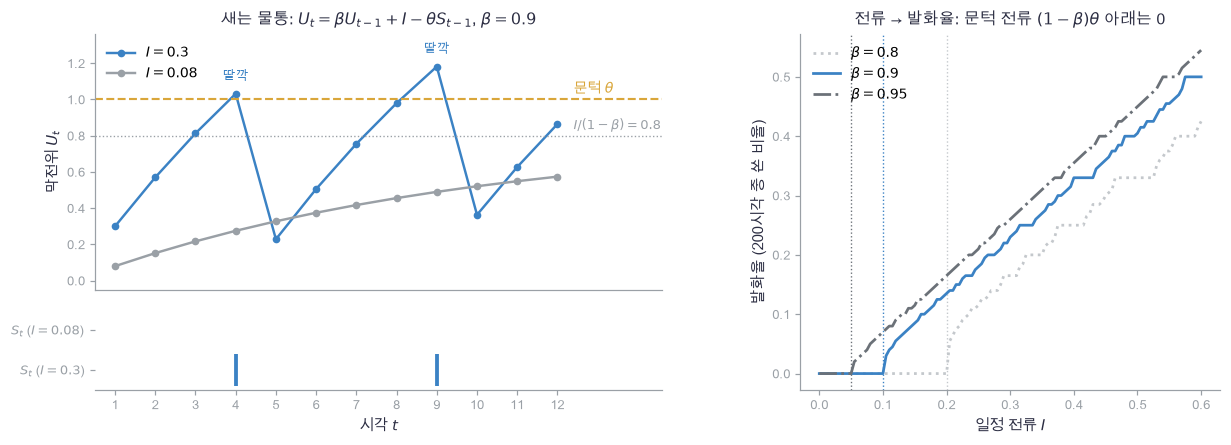

In [5]:
plot_lif_trace(np.arange(1, 13), hand_U, hand_S, hand_I, hand_theta, hand_beta, hand_steady, fi_currents, fi_rates, fi_betas, fi_T)

🔍 **확인** · 왼쪽 파란 줄기($I=0.3$)는 4시각에 처음 문턱을 넘습니다($U_4=1.0317$). 다음 시각의 막전위는 0으로 돌아가지 않고 $0.9\times1.0317+0.3-1=0.2285$에서 다시 오르며, 9시각에 두 번째로 쏩니다. 뺄셈 리셋은 새어 줄어든 막전위 $\beta U_4=0.9285$에서 $\theta=1$을 빼므로, 넘친 양이 이번처럼 작으면($U_4-\theta=0.0317$) 막전위를 버리고 전류 $0.3$만 남기는 0 리셋보다 오히려 낮은 곳에서 다시 시작합니다. 두 리셋의 출발점 차이는 $\beta U_4-\theta$라서, 넘친 양이 $\theta(1-\beta)/\beta\approx0.111$보다 커야 뺄셈 리셋 쪽이 더 높은 곳에서 시작합니다(연습 B). 회색 줄기($I=0.08$)는 점선 $I/(1-\beta)=0.8$을 향해 오르기만 하고 문턱에 닿지 않습니다.
오른쪽에서 발화율은 점선(문턱 전류 $(1-\beta)\theta$) 아래에서 정확히 0이고, 그 위에서는 전류가 클수록 자주 쏩니다. 같은 전류 $I=0.3$에서 덜 새는 뉴런($\beta=0.95$)일수록 자주 쏩니다. 출력이 0/1이어도 **발화율**은 전류의 세기를 담습니다. 2절과 5절이 이 성질을 씁니다.

아래 구현은 배치 $N$·뉴런 $H$개를 한 번에 돌리고, 4절의 backward에 쓰려고 모든 시각의 막전위 $U$를 남깁니다.

> **코드** · `np.tile(hand_I, (1, 12, 1))`: `(2,)`를 `(1, 12, 2)`로 반복해 "배치 1개, 12시각 동안 같은 전류"를 만듭니다. 검산 셀의 `np.tile(fi_currents, (1, fi_T, 1))`도 같은 방식으로 `(1, 200, 121)`입니다.

In [6]:
def lif_forward(I, beta, theta):
    """LIF forward (뺄셈 리셋): 시각마다 U_t = βU_{t−1} + I_t − θS_{t−1}, S_t = Θ(U_t − θ). U_0 = S_0 = 0.
    I: (N, T, H) 입력 전류, beta·theta: 숫자 → (U: (N, T, H) 막전위, S: (N, T, H) 0/1 스파이크)."""
    N, T, H = I.shape
    U = np.zeros((N, T, H))
    S = np.zeros((N, T, H))
    u = np.zeros((N, H))                                   # U_0 = 0
    s = np.zeros((N, H))                                   # S_0 = 0
    for t in range(T):                                     # 시각 순서대로
        u = beta * u + I[:, t] - theta * s                 # (N, H): 새고, 더하고, 직전 스파이크만큼 뺌
        s = (u >= theta).astype(float)                     # (N, H): 문턱 이상이면 1
        U[:, t] = u
        S[:, t] = s
    return U, S

In [7]:
# 쓰는 것: hand_I, hand_U, hand_S (1절 손계산 셀) · fi_currents, fi_betas, fi_rates, fi_T (1절 발화율 셀)
lif_U, lif_S = lif_forward(np.tile(hand_I, (1, 12, 1)), 0.9, 1.0)         # (1, 12, 2): 손계산과 같은 두 뉴런
np.testing.assert_allclose(lif_U[0], hand_U)                              # 검산: 함수의 막전위 = 손계산 표
np.testing.assert_array_equal(lif_S[0], hand_S)                           # 검산: 스파이크 시각도 같음
quiet_t = np.arange(1, 13)
np.testing.assert_allclose(hand_U[:, 1], 0.08 * (1 - 0.9 ** quiet_t) / (1 - 0.9))   # 검산: 쏘지 않는 뉴런은 닫힌 식 I(1 − β^t)/(1 − β)
_, flat_S = lif_forward(np.full((1, 20, 1), 0.25), 1.0, 1.0)             # 누설 없음(β = 1): 0.25씩 4번 모이면 1
np.testing.assert_array_equal(np.flatnonzero(flat_S[0, :, 0]) + 1, [4, 8, 12, 16, 20])   # 검산: 손계산. 4시각마다 한 번
for i, beta in enumerate(fi_betas):
    _, fi_S = lif_forward(np.tile(fi_currents, (1, fi_T, 1)), beta, 1.0)  # (1, 200, 121)
    np.testing.assert_allclose(fi_S[0].mean(axis=0), fi_rates[i])         # 검산: 발화율 곡선 = 함수로 잰 비율
print("lif_forward: 손계산 표·닫힌 식·β = 1의 4시각 간격·발화율 곡선과 일치합니다.")

lif_forward: 손계산 표·닫힌 식·β = 1의 4시각 간격·발화율 곡선과 일치합니다.


🔍 **확인** · 반복문 함수가 손계산 두 줄기, 쏘지 않는 뉴런의 닫힌 식 $I(1-\beta^t)/(1-\beta)$, 그리고 발화율 곡선 세 개를 그대로 냅니다. 누설이 없으면($\beta=1$) 0.25씩 4번 모여 1이 되는 순간마다 쏘고, 뺄셈 리셋이라 남는 양이 정확히 0이어서 4시각 간격이 유지됩니다.

📎 **왜 $\beta$라고 부르나.** 연속 시간의 LIF는 $\tau\,\dfrac{dU}{dt}=-U+RI$입니다(시간 상수 $\tau$, 저항 $R$). 입력이 없으면 $U(t+\Delta t)=U(t)\,e^{-\Delta t/\tau}$이므로 간격 $\Delta t$마다 끊어 보면 $\beta=e^{-\Delta t/\tau}$입니다. $\Delta t=1$ms, $\beta=0.9$이면 $\tau=-1/\ln0.9\approx9.5$ms입니다. 이 노트북은 시각을 정수로만 세고 입력 항의 계수 $(1-\beta)R$ 같은 것은 가중치에 흡수했다고 봅니다.

### ✏️ 연습 1 · 쏘기 전까지는 닫힌 식

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

일정한 전류 `I`를 받는 뉴런이 아직 쏘지 않았다면 반복문 없이 $U_t=I\,(1-\beta^t)/(1-\beta)$입니다. 시각 배열 `t` `(T,)` = 1, 2, …, T는 써 두었습니다. 이 식으로 `U` `(T,)`를 만드는 한 줄을 채우세요. 검사는 1절 손계산 표(첫 스파이크 전까지)와 쏘지 않는 뉴런, 그리고 문턱을 처음 넘는 시각으로 합니다.

> **코드** · `np.argmax(U >= 1.0)`: True/False 배열에서 처음 True인 자리의 번호. True를 1, False를 0으로 보고 가장 큰 값이 처음 나오는 자리를 찾기 때문입니다. 검사 함수가 첫 스파이크 시각을 찾을 때 씁니다.

In [8]:
def exercise_leaky_integral(I, beta, T):
    """연습 1: 쏘기 전 막전위의 닫힌 식 U_t = I(1 − β^t)/(1 − β). I·beta: 숫자 (0 < β < 1), T: 정수 → U: (T,), 원소 t−1이 U_t."""
    assert 0 < beta < 1, "닫힌 식은 0 < β < 1에서 씁니다"
    t = np.arange(1, T + 1)                          # (T,): 시각 1, 2, …, T
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: U = I · (1 − β^t) / (1 − β) 를 배열 t에 대해 한 번에 (모양 (T,))
    ### 힌트: 1절 🔑의 "언제 쏘지 않나" 식입니다. beta ** t 는 원소마다 거듭제곱합니다.
    raise NotImplementedError
    return U

In [9]:
def check_leaky_integral(candidate):
    """1절 손계산 표와 lif_forward로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: hand_U, hand_S (1절 손계산 셀) · lif_forward (1절)
    U = candidate(0.3, 0.9, 4)
    assert np.shape(U) == (4,), f"U는 (T,) = (4,)여야 하는데 {np.shape(U)}입니다"
    np.testing.assert_allclose(U, [0.3, 0.57, 0.813, 1.0317])                  # 검산: 손계산 0.3, 0.3·0.9 + 0.3, …
    np.testing.assert_allclose(U, hand_U[:4, 0])                               # 검산: 1절 표의 첫 스파이크(4시각)까지
    first = int(np.argmax(candidate(0.3, 0.9, 12) >= 1.0)) + 1                 # 처음 문턱 이상이 되는 시각
    assert first == np.flatnonzero(hand_S[:, 0])[0] + 1, "닫힌 식으로 찾은 첫 스파이크 시각이 1절 표와 같아야 합니다"
    np.testing.assert_allclose(candidate(0.08, 0.9, 12), hand_U[:, 1])         # 검산: 쏘지 않는 뉴런은 12시각 모두
    U_fn, S_fn = lif_forward(np.full((1, 50, 1), 0.04), 0.95, 1.0)             # U* = 0.04/0.05 = 0.8 < 1: 쏘지 않음
    np.testing.assert_allclose(candidate(0.04, 0.95, 50), U_fn[0, :, 0])       # 검산: lif_forward와 같음
    print("쏘기 전의 닫힌 식: 손계산·lif_forward와 일치합니다.")

run_check(check_leaky_integral, exercise_leaky_integral, hint="U = I * (1 - beta ** t) / (1 - beta)")

☐ exercise_leaky_integral: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: U = I * (1 - beta ** t) / (1 - beta)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
U = I * (1 - beta ** t) / (1 - beta)
```

</details>

## 🔑 2. 스파이크로 부호화: 밝기를 켜질 확률로

**이 절에서 가져갈 것:** 화소 밝기 $x_d\in[0,1]$를 시각마다 독립으로 $S^{in}_{t,d}\sim\mathrm{Bernoulli}(x_d)$에서 뽑으면, $T$시각 평균 $\bar S_d=\frac1T\sum_tS^{in}_{t,d}$의 기댓값은 $x_d$이고 표준편차는 $\sqrt{x_d(1-x_d)/T}$입니다. 시각을 4배로 늘리면 흔들림이 절반으로 줄어듭니다.

1절의 뉴런은 실수 전류를 받았습니다. 그런데 SNN에서는 뉴런끼리 0/1만 주고받으므로, 첫 층에 들어갈 이미지도 스파이크로 바꿔야 합니다. 물통 비유로는 화소마다 수도꼭지가 하나 있고, 밝은 화소일수록 자주 한 방울씩 떨어뜨립니다.
한 시각만 보면 방울이 떨어졌는지(1) 아닌지(0)뿐이지만, 여러 시각 동안 센 비율은 밝기에 가까워집니다. 동전을 여러 번 던질수록 앞면 비율이 확률에 가까워지는 것과 같습니다.

> **용어**
>
> - **부호화(encoding)**: 실수 입력을 스파이크 열 $(T, D)$로 바꾸는 규칙.
> - **rate coding**: 밝기를 "시각마다 켜질 확률"로 쓰는 부호화. 정보가 스파이크의 **빈도**에 있습니다. 코드에서는 `rng.random((T, D)) < x`.
> - **latency coding**: 밝을수록 **일찍** 한 번만 쏘는 부호화. 정보가 스파이크의 **시각**에 있습니다. 이 노트북은 rate coding으로 학습하고 latency coding은 그림으로만 봅니다.
> - **래스터 그림(raster plot)**: 가로 = 뉴런(또는 화소), 세로 = 시각으로 두고 스파이크 자리만 검게 칠한 그림. 3·5절에서 씁니다.
> - **RMS(root mean square, 제곱평균제곱근)**: 여러 값을 제곱해 평균낸 뒤 제곱근을 씌운 값. 부호와 상관없이 차이의 전형적인 크기를 원래 단위의 숫자 하나로 요약합니다. 코드에서는 `np.sqrt(np.mean((noise_S[:T].mean(axis=0) - mnist_7_flat) ** 2))`.

02번 7절의 Bernoulli 관측처럼 $S^{in}_{t,d}$는 확률 $x_d$로 1, $1-x_d$로 0이므로 평균 $x_d$, 분산 $x_d(1-x_d)$입니다. 서로 독립인 $T$개를 더하면 분산도 더해지고, $T$로 나누면 분산은 $T^2$으로 나뉩니다.

$$S^{in}_{t,d}\sim\mathrm{Bernoulli}(x_d),\qquad \mathbb E\big[\bar S_d\big]=x_d,\qquad \mathrm{Var}\big[\bar S_d\big]=\frac{T\,x_d(1-x_d)}{T^2}=\frac{x_d(1-x_d)}{T}.$$

$T$시각 평균은 평균적으로 밝기와 같고, 그 흔들림(표준편차)은 $1/\sqrt T$로 줄어듭니다. 01b번 2절에서 배치 기울기의 흔들림이 $1/\sqrt B$로 줄던 것과 같은 이유입니다. 흔들림이 가장 큰 화소는 $x_d=0.5$이고, 완전히 흰($x_d=0$) 화소와 완전히 검은($x_d=1$) 화소는 흔들리지 않습니다.

| 기호 | shape | 뜻 |
|---|---|---|
| $x$ | $(D,)$ 또는 $(N, D)$ | 화소 밝기, $D=784$ |
| $S^{in}$ | $(T, D)$ 또는 $(N, T, D)$ | 입력 스파이크 0/1 |
| $\bar S$ | $(D,)$ 또는 $(N, D)$ | 시간 평균 = 발화율 |

아래는 7을 64시각 동안 부호화해 처음 세 시각의 프레임과 $T=4, 16, 64$의 평균을 만들고, 시각 수를 1부터 256까지 바꾸며 평균과 밝기의 차이가 화소 전체에서 얼마나 되는지 RMS로 잽니다.

> **코드**
>
> - `rng_code.random((64, 784)) < mnist_7_flat`: 0–1 균등 난수 `(64, 784)`와 밝기 `(784,)`를 뒤 축부터 맞춰 비교합니다. 난수가 밝기보다 작을 확률이 곧 밝기이므로, True가 확률 $x_d$로 나옵니다.
> - `code_S[:T].mean(axis=0)`: 앞 T시각만 잘라 시각 축으로 평균 → `(784,)`.
> - `np.where(조건, a, b)`: 조건이 True인 자리는 a, 아니면 b. latency 그림에서 잉크가 없는 화소를 NaN(흰색)으로 둡니다.

In [10]:
# 쓰는 것: mnist_7_flat (📎 데이터 셀)
rng_code = np.random.default_rng(7)
code_S = (rng_code.random((64, 784)) < mnist_7_flat).astype(float)   # (T, D) = (64, 784): 시각마다 화소마다 Bernoulli(x_d)
code_Ts = [4, 16, 64]
code_means = [code_S[:T].mean(axis=0) for T in code_Ts]              # 3개의 (784,): 앞 T시각의 평균
code_frames = code_S[:3]                                             # (3, 784): 시각 1·2·3의 스파이크 프레임
print("시각마다 켜진 화소 수 (앞 8시각):", code_S[:8].sum(axis=1))
print("기댓값 = 밝기 합:", round(mnist_7_flat.sum(), 2), "· 64시각 평균의 합:", code_S.sum(axis=1).mean())
print("잉크 화소", np.count_nonzero(mnist_7_flat), "중 밝기 0.9 이상", np.sum(mnist_7_flat >= 0.9), "· 0.5 미만", np.sum((mnist_7_flat > 0) & (mnist_7_flat < 0.5)))

시각마다 켜진 화소 수 (앞 8시각): [53. 51. 54. 52. 53. 49. 46. 48.]
기댓값 = 밝기 합: 49.55 · 64시각 평균의 합: 49.6875
잉크 화소 83 중 밝기 0.9 이상 23 · 0.5 미만 31


In [11]:
# 쓰는 것: mnist_7_flat (📎 데이터 셀)
noise_Ts = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])
noise_S = np.random.default_rng(8).random((256, 784)) < mnist_7_flat          # (256, 784): True/False 스파이크
noise_measured = np.array([np.sqrt(np.mean((noise_S[:T].mean(axis=0) - mnist_7_flat) ** 2))
                           for T in noise_Ts])                                  # (9,): 화소 784개에 걸친 차이의 제곱평균제곱근(RMS)
noise_theory = np.sqrt(np.mean(mnist_7_flat * (1 - mnist_7_flat)) / noise_Ts)  # (9,): √(mean_d x_d(1 − x_d) / T)
latency_T = 16
latency_map = np.where(mnist_7_flat > 0, np.round((1 - mnist_7_flat) * (latency_T - 1)) + 1, np.nan)   # (784,): 밝을수록 이른 시각
print("T:", noise_Ts)
print("잰 값:", noise_measured.round(4))
print("이론 :", noise_theory.round(4))
print("latency: 가장 이른 시각", np.nanmin(latency_map), "· 쏘는 화소", np.count_nonzero(mnist_7_flat))

T: [  1   2   4   8  16  32  64 128 256]
잰 값: [0.1111 0.0904 0.0546 0.0413 0.028  0.0207 0.0158 0.0105 0.0079]
이론 : [0.1149 0.0812 0.0574 0.0406 0.0287 0.0203 0.0144 0.0102 0.0072]
latency: 가장 이른 시각 1.0 · 쏘는 화소 83


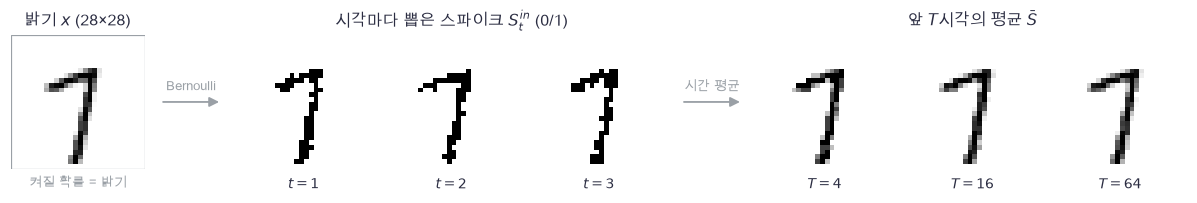

In [12]:
plot_rate_coding(mnist_7, code_frames, [1, 2, 3], code_means, code_Ts)

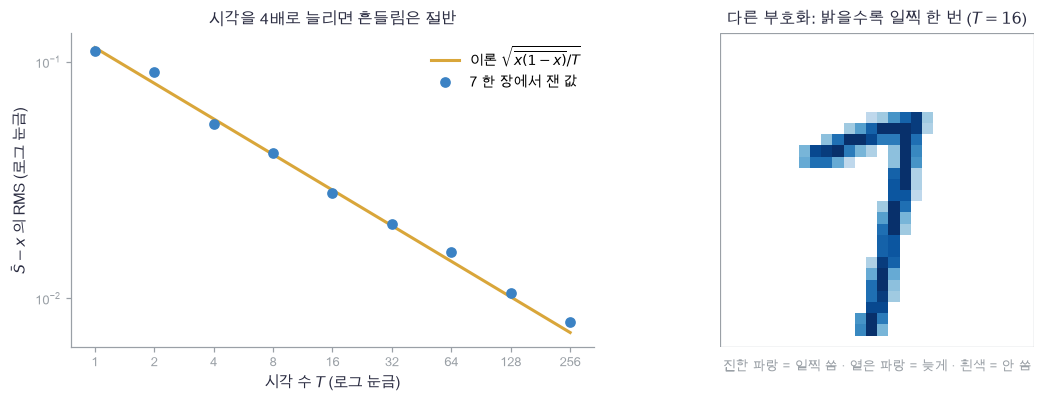

In [13]:
plot_coding_noise(noise_Ts, noise_measured, noise_theory, latency_map, latency_T)

🔍 **확인** · 첫 그림에서 한 시각의 프레임은 0/1뿐이라 회색이 없습니다. 이 7의 진한 화소(위 출력의 밝기 0.9 이상 23개)는 거의 매 시각 켜지고, 옅은 화소(0.5 미만 31개)는 켜졌다 꺼졌다 해서 프레임마다 획의 테두리가 조금씩 다릅니다. 시각마다 켜진 화소 수(위 출력의 46–54개)의 기댓값은 밝기 합 49.55입니다. 앞 4시각의 평균은 테두리가 거칠지만, 16·64시각으로 늘리면 원래 이미지의 옅고 진한 정도가 돌아옵니다.
둘째 그림 왼쪽의 세로축은 화소 784개에 걸친 $\bar S-x$의 RMS이고, 이론선은 분산 $x_d(1-x_d)/T$를 화소에 걸쳐 평균낸 뒤 제곱근을 씌운 $\sqrt{\overline{x(1-x)}/T}$입니다. 잰 값(파랑)이 이론선(금색)을 따라 로그 눈금 위의 직선으로 내려갑니다. 위 출력에서 $T=4$의 0.0546이 $T=16$에서 0.028, $T=64$에서 0.0158로, 4배마다 대략 절반입니다(이론 0.0574 → 0.0287 → 0.0144). 오른쪽은 같은 7을 latency coding으로 바꾼 것으로, 획 가운데가 가장 이른 시각에 한 번 쏩니다.

아래 구현은 배치 $N$장을 한 번에 부호화합니다. 5절의 학습에서는 배치마다 이 함수를 새로 부르므로, 같은 이미지도 에폭(01b번 3절: 학습 집합을 한 번 다 쓰는 단위)마다 다른 스파이크 열로 들어갑니다.

> **코드**
>
> - `X[:, None, :]`: `(N, D)`를 `(N, 1, D)`로 세워, 난수 `(N, T, D)`와 비교할 때 시각 축으로 복제되게 합니다.
> - `mnist_7_flat[None]`: `(784,)` 한 장을 앞에 축 하나를 세운 `(1, 784)`, 곧 한 장짜리 배치로 만듭니다. 검산 셀과 5절에서 한 장을 `rate_encode`에 넣을 때 씁니다.

In [14]:
def rate_encode(X, T, rng):
    """rate coding: 시각마다 독립으로 S^in_{n,t,d} ~ Bernoulli(X[n, d]).
    X: (N, D) 밝기 ∈ [0, 1], T: 시각 수, rng: 난수 생성기 → Sin: (N, T, D) 0/1 실수 배열."""
    N, D = X.shape
    return (rng.random((N, T, D)) < X[:, None, :]).astype(float)   # 난수 (N, T, D) < 밝기 (N, 1, D)

In [15]:
# 쓰는 것: mnist_7_flat (📎 데이터 셀) · code_S (2절 부호화 셀)
same_S = rate_encode(mnist_7_flat[None], 64, np.random.default_rng(7))   # (1, 64, 784): 부호화 셀과 같은 seed
np.testing.assert_array_equal(same_S[0], code_S)                         # 검산: 같은 난수 순서라 그림의 프레임과 같음
probe_x = np.array([0.0, 0.25, 0.5, 1.0])                                # (4,): 화소 네 개의 밝기
probe_S = rate_encode(np.tile(probe_x, (4000, 1)), 50, np.random.default_rng(9))   # (4000, 50, 4): 같은 밝기를 4,000번 부호화
probe_mean = probe_S.mean(axis=1)                                        # (4000, 4): 한 번마다 T = 50 평균
np.testing.assert_allclose(probe_mean.mean(axis=0), probe_x, atol=0.005)   # 검산: 평균의 기댓값 = 밝기
np.testing.assert_allclose(probe_mean.std(axis=0), np.sqrt(probe_x * (1 - probe_x) / 50), rtol=0.05)   # 검산: 표준편차 = √(x(1 − x)/T)
assert np.all(probe_S[:, :, 0] == 0), "밝기 0인 화소는 한 번도 켜지면 안 됩니다"
assert np.all(probe_S[:, :, 3] == 1), "밝기 1인 화소는 매 시각 켜져야 합니다"
print("평균:", probe_mean.mean(axis=0).round(4), "· 표준편차:", probe_mean.std(axis=0).round(4),
      "· 이론:", np.sqrt(probe_x * (1 - probe_x) / 50).round(4))

평균: [0.     0.2499 0.4998 1.    ] · 표준편차: [0.     0.0615 0.0706 0.    ] · 이론: [0.     0.0612 0.0707 0.    ]


🔍 **확인** · 같은 seed면 함수가 부호화 셀의 프레임을 그대로 냅니다. 밝기 0.25와 0.5인 화소를 4,000번씩 $T=50$으로 부호화하면 평균의 평균은 밝기와, 표준편차는 $\sqrt{x(1-x)/50}$과 위 출력처럼 맞습니다. 밝기 0과 1은 흔들리지 않습니다.

### ✏️ 연습 2 · 난수와 밝기를 비교해 스파이크 만들기

균등 난수 `u` `(T, D)`가 이미 뽑혀 있다고 하고, 밝기 `x` `(D,)`로 rate coding 스파이크 `S` `(T, D)`(0/1 실수)를 만드는 한 줄을 채우세요. 시간 평균 `rate`는 써 두었습니다. 난수를 인자로 받으므로 결과가 정해져 손계산으로 검사할 수 있습니다.

In [16]:
def exercise_rate_code(x, u):
    """연습 2: 난수 u가 밝기 x보다 작은 자리를 1로. x: (D,) ∈ [0, 1], u: (T, D) 균등 난수 → (S: (T, D) 0/1, rate: (D,) 시간 평균)."""
    assert u.shape[1] == x.shape[0], "난수의 열 수 D가 화소 수와 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: S = (u < x)를 0/1 실수로 바꾼 (T, D) 배열. x (D,)는 뒤 축부터 맞춰 모든 시각에 쓰입니다
    ### 힌트: 2절 부호화 셀의 한 줄에서 rng_code.random((64, 784)) 자리에 u 를 넣습니다. .astype(float)
    raise NotImplementedError
    rate = S.mean(axis=0)
    return S, rate

In [17]:
def check_rate_code(candidate):
    """손계산 하나와 2절 부호화 셀(같은 seed의 난수)로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mnist_7_flat (📎 데이터 셀) · code_S (2절 부호화 셀)
    x = np.array([0.2, 0.7, 0.0])
    u = np.array([[0.1, 0.9, 0.0],
                  [0.5, 0.3, 0.4],
                  [0.15, 0.7, 0.9]])                                     # (T, D) = (3, 3)
    S, rate = candidate(x, u)
    assert np.shape(S) == (3, 3), f"S는 (T, D) = (3, 3)이어야 하는데 {np.shape(S)}입니다"
    np.testing.assert_array_equal(S, [[1, 0, 0], [0, 1, 0], [1, 0, 0]])   # 검산: 0.1 < 0.2, 0.3 < 0.7, 0.15 < 0.2만 켜짐 (0.7 < 0.7은 아님, 0 < 0도 아님)
    np.testing.assert_allclose(rate, [2 / 3, 1 / 3, 0])                   # 검산: 시각 평균
    u_code = np.random.default_rng(7).random((64, 784))                   # 2절 부호화 셀과 같은 난수
    np.testing.assert_array_equal(candidate(mnist_7_flat, u_code)[0], code_S)   # 검산: 2절 그림의 프레임과 같음
    print("rate coding 한 줄: 손계산·2절 부호화와 일치합니다.")

run_check(check_rate_code, exercise_rate_code, hint="S = (u < x).astype(float)")

☐ exercise_rate_code: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: S = (u < x).astype(float)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
S = (u < x).astype(float)
```

</details>

## 🔑 3. 층을 시간으로 펼치기: 0/1 입력의 행렬곱은 행 더하기

**이 절에서 가져갈 것:** 입력 스파이크 $S^{in}$ $(N,T,D)$에 $W_1$ $(D,H)$를 곱한 전류 $I_t=S^{in}_tW_1+b_1$을 1절의 LIF에 넣어 은닉 스파이크 $S$ $(N,T,H)$를 얻고, 읽기층 $\frac1T\sum_t(S_tW_2+b_2)$로 logit $(N,K)$을 만듭니다. $s\in\{0,1\}^D$이면 `s @ W1`은 켜진 입력 $d$의 행 `W1[d]`를 더한 것과 같아서, 이 층의 전류는 곱셈 없이 (켜진 입력 수 × $H$)번의 덧셈으로 끝납니다.

2절에서 7을 스파이크 열로 바꿨습니다. 이제 이 입력을 은닉 LIF 뉴런 $H$개에 연결합니다. 입력 화소 $d$에서 은닉 뉴런 $h$로 가는 선마다 가중치 $W_{1,dh}$가 있고, 시각 $t$에 켜진 화소들의 가중치가 뉴런마다 전류로 모입니다. 물통 비유로는 **켜진 수도꼭지만** 자기 몫의 물(양수면 붓고 음수면 퍼냄)을 보탭니다.
은닉 뉴런의 스파이크는 다시 읽기층 $W_2$를 지나 숫자 10개의 점수가 되고, 5절에서 05b번처럼 softmax CE를 붙입니다.

> **용어**
>
> - **시냅스(synapse)**: 한 뉴런의 출력이 다른 뉴런의 입력으로 이어지는 연결. 가중치 행렬의 원소 하나가 시냅스 하나입니다.
> - **시냅스 연산(synaptic operation)**: 스파이크 하나가 시냅스 하나를 지나며 가중치를 막전위에 **더하는** 한 번. 실수 입력의 층은 원소마다 곱하고 더하지만, 0/1 입력은 켜진 자리의 가중치를 더하기만 합니다.
> - **읽기층(readout)**: 은닉 스파이크를 실수 logit으로 바꾸는 마지막 선형층. 여기서는 시각마다의 점수 $S_tW_2+b_2$를 시간 평균합니다.
> - **스파이크 수(spike count)** $C$ $(N,H)$: 뉴런마다 $T$시각 동안 쏜 횟수 `S.sum(axis=1)`. 발화율은 $C/T$입니다.

$$I_t=S^{in}_tW_1+b_1\ \ (N,H),\qquad (U,S)=\mathrm{LIF}(I_1,\ldots,I_T),\qquad \mathrm{logits}=\frac1T\sum_{t=1}^{T}\big(S_tW_2+b_2\big)=\frac1T\Big(\sum_tS_t\Big)W_2+b_2\ \ (N,K).$$

시각마다 켜진 입력으로 전류를 만들어 LIF를 한 시각 진행하고, 모든 시각의 은닉 스파이크에서 나온 점수를 평균해 logit으로 씁니다. 마지막 등식은 시간 평균이 **뉴런별 스파이크 수** $C=\sum_tS_t$ $(N,H)$에 $W_2/T$를 곱한 것과 같다는 뜻입니다.

| 기호 | shape | 역할 |
|---|---|---|
| $S^{in}$ | $(N, T, D)$ | 2절의 입력 스파이크, $D=784$ |
| $W_1,\ b_1$ | $(D, H),\ (H,)$ | 입력 → 은닉 전류. 행 $d$가 화소 $d$의 가중치 |
| $U,\ S$ | $(N, T, H)$ | 은닉 LIF의 막전위와 스파이크 |
| $W_2,\ b_2$ | $(H, K),\ (K,)$ | 은닉 스파이크 → 점수, $K=10$ |
| logits | $(N, K)$ | 시간 평균 점수 |

**왜 이 읽기층인가.** 출력층까지 LIF로 두고 스파이크 수를 점수로 쓰는 설계도 있지만, 그러면 점수가 0과 $T$ 사이의 정수가 되고 backward에 LIF가 하나 더 붙습니다. 시간 평균 선형 읽기는 점수가 실수라 02번 8절의 softmax CE를 그대로 쓸 수 있고, backward가 03번 5절의 선형층 세 식입니다. 이 노트북은 LIF의 학습에 집중하려고 이 읽기층을 씁니다.

**0/1 입력의 행렬곱.** 행 벡터 $s\in\{0,1\}^D$와 $W_1$의 곱은 $h$번째 열이 $\sum_d s_dW_{1,dh}$입니다. $s_d$가 0인 항은 사라지고 1인 항은 가중치 그대로 남으므로
$$sW_1=\sum_{d:\,s_d=1}W_1[d]\qquad(\text{켜진 입력의 행을 더함}).$$
시각 $t$ 한 번에 필요한 덧셈은 (켜진 입력 수)×$H$번이고, 은닉 스파이크가 읽기층을 지날 때는 (켜진 은닉 수)×$K$번입니다. 이 노트북은 연산 **횟수**만 셉니다. 실제 하드웨어의 전력은 메모리 접근 등 다른 요인에 달려 있어 여기서 비교하지 않습니다. 또 이 횟수는 시냅스 연산만 센 것이고, LIF의 누설 $\beta U$에는 뉴런마다 시각마다 곱셈 한 번(장당 $T\cdot H$번)이 따로 듭니다.

아래는 먼저 작은 손계산(입력 6개, 은닉 4개)으로 행 더하기를 보고, 그다음 학습 전 난수 가중치로 7의 스파이크 16시각을 은닉 128개에 통과시킵니다. 전류는 행렬곱 대신 **켜진 행의 합**으로 직접 만듭니다.

> **코드**
>
> - `toy_W[toy_s == 1]`: 조건이 True인 행만 골라 `(켜진 수, 4)`. `.sum(axis=0)`이 행들을 더해 `(4,)`.
> - `flow_S.sum(axis=0)`: `(T, H)`를 시각 축으로 더한 뉴런별 스파이크 수 `(H,)`.
> - `flow_Sin.sum()`: 16시각 동안 켜진 입력 스파이크의 총수. 여기에 $H$를 곱하면 첫 층의 덧셈 횟수입니다.
> - `np.stack([a, b, …])`: 같은 모양 `(128,)` 배열들을 새 앞 축으로 쌓아 `(개수, 128)`. 검산 셀에서 입력 40개의 행 더하기 결과를 한 배열로 모읍니다.

In [18]:
toy_s = np.array([1., 0., 1., 1., 0., 0.])          # (D,) = (6,): 입력 0·2·3이 켜짐
toy_W = np.array([[2., -1., 0., 1.],
                  [5., 5., 5., 5.],
                  [-1., 2., 1., 0.],
                  [0., 1., -2., 3.],
                  [4., -4., 4., -4.],
                  [9., 0., 9., 0.]])               # (D, H) = (6, 4): 행 d = 입력 d가 은닉 4개에 주는 가중치
toy_rows = toy_W[toy_s == 1]                       # (3, 4): 켜진 행만
toy_sum = toy_rows.sum(axis=0)                     # (4,): 행 더하기
toy_product = toy_s @ toy_W                        # (4,): 행렬곱
print("켜진 행의 합:", toy_sum, "· 행렬곱:", toy_product)

켜진 행의 합: [ 1.  2. -1.  4.] · 행렬곱: [ 1.  2. -1.  4.]


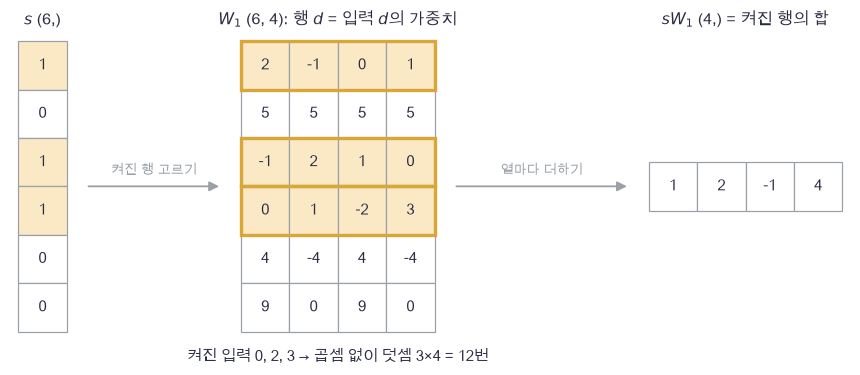

In [19]:
plot_row_sum(toy_s, toy_W, toy_sum)

In [20]:
# 쓰는 것: mnist_7_flat (📎 데이터 셀) · code_S (2절 부호화 셀)
rng_flow = np.random.default_rng(30)
flow_H = 128
flow_p = {"W1": rng_flow.normal(size=(784, flow_H)) * np.sqrt(2 / 784), "b1": np.zeros(flow_H),     # 입력 → 은닉, He 초기화 (04번 9절)
          "W2": rng_flow.normal(size=(flow_H, 10)) * np.sqrt(1 / flow_H), "b2": np.zeros(10)}      # 은닉 → logit, 분산 1/H
flow_Sin = code_S[:16]                              # (T, D) = (16, 784): 2절 7의 스파이크 앞 16시각
flow_S = np.zeros((16, flow_H))                     # (16, 128): 은닉 스파이크
u = np.zeros(flow_H)
s = np.zeros(flow_H)
for t in range(16):
    current = flow_p["W1"][flow_Sin[t] == 1].sum(axis=0) + flow_p["b1"]   # (H,): 켜진 행만 더한 전류 I_t
    u = 0.9 * u + current - 1.0 * s                                      # 1절 LIF 한 스텝 (β = 0.9, θ = 1)
    s = (u >= 1.0).astype(float)
    flow_S[t] = s
flow_logits = flow_S.sum(axis=0) @ flow_p["W2"] / 16 + flow_p["b2"]     # (10,): (1/T) C W2 + b2
flow_ops = flow_Sin.sum() * flow_H + flow_S.sum() * 10                   # 시냅스 연산(덧셈) 횟수
flow_dense = 784 * flow_H + flow_H * 10                                  # 실수 입력 MLP가 0까지 모두 곱할 때의 곱셈 횟수
flow_sparse = np.count_nonzero(mnist_7_flat) * flow_H + flow_H * 10      # 0인 화소를 건너뛰는 MLP (은닉 128개는 모두 곱한다고 본 상한)
print(f"입력 스파이크 {flow_Sin.sum():.0f}개 · 은닉 스파이크 {flow_S.sum():.0f}개 (발화율 {flow_S.mean():.3f}) · logit 최대 자리 {flow_logits.argmax()}")
print(f"16시각의 덧셈 {flow_ops:,.0f}번 · 같은 크기 MLP(784 → 128 → 10)의 곱셈: 0까지 모두 {flow_dense:,}번, 0인 화소를 건너뛰면 {flow_sparse:,}번")

입력 스파이크 805개 · 은닉 스파이크 142개 (발화율 0.069) · logit 최대 자리 4
16시각의 덧셈 104,460번 · 같은 크기 MLP(784 → 128 → 10)의 곱셈: 0까지 모두 101,632번, 0인 화소를 건너뛰면 11,904번


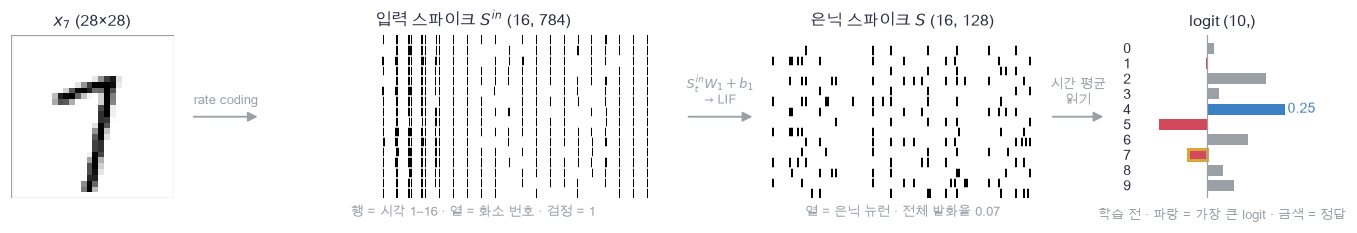

In [21]:
plot_snn_flow(mnist_7, flow_Sin, flow_S, flow_logits, 7)

🔍 **확인** · 손계산 그림에서 켜진 입력 0·2·3의 행(금색 틀)만 더하면 $[1, 2, -1, 4]$이고 행렬곱과 같습니다. 꺼진 행에 5나 9처럼 큰 값이 있어도 결과에 들어오지 않습니다. 덧셈은 3×4 = 12번이면 됩니다.
둘째 그림에서 입력 래스터는 7의 잉크가 있는 화소 번호(열)에만 세로줄이 생깁니다. 밝기가 거의 1인 화소는 16시각 내내 켜져 줄이 이어지고, 옅은 화소는 줄이 끊깁니다. 은닉 래스터는 학습 전 난수 가중치라 뉴런 대부분이 드물게 쏘고(발화율 0.069) 몇몇만 여러 번 쏩니다. logit은 뜻이 없고 정답 7(금색)은 가장 크지도 않습니다.
위 출력처럼 16시각 동안 입력 스파이크는 805개라 첫 층의 덧셈이 805×128 = 103,040번이고, 은닉 스파이크 142개의 읽기 덧셈 1,420번을 더하면 104,460번입니다. 같은 크기 MLP가 0인 화소까지 모두 곱하면 101,632번으로 비슷한 규모지만, 이 7은 0이 아닌 화소가 83개뿐이라 0을 건너뛰는 MLP는 83×128 + 1,280 = 11,904번이면 됩니다. SNN의 덧셈 수도 0인 화소에서는 스파이크가 없어 이미 0을 건너뛴 값이므로, 견줄 기준은 뒤의 11,904번입니다. SNN은 켜진 화소를 16시각 동안 여러 번 더하므로 그보다 많습니다. 덧셈 횟수는 시각 수 $T$에 비례하므로, 5절에서 $T$를 바꿔 정확도와 함께 봅니다.

아래 구현은 배치 $N$장을 한 번에 처리하므로 전류를 행렬곱 `Sin @ W1`로 만듭니다. 결과는 켜진 행의 합과 같고, 검산 셀에서 확인합니다. LIF 함수는 인자 `lif`로 받습니다. 4절에서 같은 자리에 부드러운 LIF를 넣어 검산합니다.

> **코드** · `def snn_forward(…, lif=lif_forward)`: 인자를 주지 않으면 1절의 `lif_forward`를 씁니다. 함수도 값처럼 인자로 넘길 수 있고, 안에서 `lif(I, beta, theta)`로 부릅니다.

In [22]:
def snn_forward(Sin, p, beta, theta, lif=lif_forward):
    """스파이크 입력 → 전류 → LIF 은닉 스파이크 → 시간 평균 읽기 logit.
    I_t = S^in_t W1 + b1, (U, S) = lif(I, β, θ), logits = (1/T) Σ_t (S_t W2 + b2) = (1/T) C W2 + b2, C = Σ_t S_t.
    Sin: (N, T, D) 0/1, p: {"W1": (D, H), "b1": (H,), "W2": (H, K), "b2": (K,)}, lif: (I, beta, theta) → (U, S)
    → (logits: (N, K), cache: (Sin, U, S))."""
    # 쓰는 것: lif_forward (1절)
    T = Sin.shape[1]
    I = Sin @ p["W1"] + p["b1"]                            # (N, T, H): 시각마다 켜진 행의 합 + 편향
    U, S = lif(I, beta, theta)                             # (N, T, H) 두 개
    logits = S.sum(axis=1) @ p["W2"] / T + p["b2"]         # (N, K): 스파이크 수 C (N, H)로 시간 평균 점수
    return logits, (Sin, U, S)

In [23]:
# 쓰는 것: flow_Sin, flow_p, flow_S, flow_logits (3절 흐름 셀) · toy_sum, toy_product (3절 손계산 셀)
np.testing.assert_allclose(toy_sum, toy_product)                              # 검산: 손계산. 켜진 행의 합 = 행렬곱
np.testing.assert_allclose(toy_sum, [1., 2., -1., 4.])                        # 검산: 손계산 [2−1+0, −1+2+1, 0+1−2, 1+0+3]
flow_check, flow_cache = snn_forward(flow_Sin[None], flow_p, 0.9, 1.0)         # 7 한 장을 배치 1개로
np.testing.assert_allclose(flow_check[0], flow_logits)                        # 검산: 행렬곱 forward = 켜진 행을 더한 반복문
np.testing.assert_array_equal(flow_cache[2][0], flow_S)                       # 검산: 은닉 스파이크도 같음
rng_rows = np.random.default_rng(31)
rows_S = (rng_rows.random((40, 784)) < 0.2).astype(float)                    # (40, 784): 임의의 0/1 입력 40개
rows_sum = np.stack([flow_p["W1"][row == 1].sum(axis=0) for row in rows_S])    # (40, 128): 행마다 켜진 행 더하기
np.testing.assert_allclose(rows_S @ flow_p["W1"], rows_sum)                  # 검산: 0/1이면 행렬곱 = 켜진 행의 합
print("snn_forward 모양: logits", flow_check.shape, "· U", flow_cache[1].shape, "· S", flow_cache[2].shape)

snn_forward 모양: logits (1, 10) · U (1, 16, 128) · S (1, 16, 128)


🔍 **확인** · 행렬곱으로 쓴 `snn_forward`가 켜진 행을 더한 반복문과 같은 logit·은닉 스파이크를 내고, 임의의 0/1 입력 40개에서도 행렬곱과 행 더하기가 같습니다. NumPy에서는 행렬곱이 더 빠르므로 구현은 행렬곱을 쓰고, "켜진 행의 합"은 연산이 무엇인지를 설명하는 식으로 씁니다.

### ✏️ 연습 3 · 켜진 행만 더해서 전류 만들기

한 시각의 입력 스파이크 `s` `(D,)`와 가중치 `W1` `(D, H)`, 편향 `b1` `(H,)`에서 **행렬곱을 쓰지 않고** 켜진 입력의 행만 골라 더한 전류 `I` `(H,)`를 만드는 한 줄을 채우세요. 검사는 3절 손계산과 7 흐름의 첫 시각, 행렬곱과의 비교, 그리고 꺼진 입력의 행을 NaN으로 바꾼 가중치로 합니다. NaN(Not a Number)은 0을 곱해도 NaN으로 남는 값이라, 꺼진 행까지 곱해 더하는 `s @ W1`은 결과가 NaN이 되어 통과하지 않고, 켜진 행만 골라 더해야 통과합니다.

In [24]:
def exercise_current_by_rows(s, W1, b1):
    """연습 3: 0/1 입력의 전류를 행 더하기로. s: (D,) 0/1, W1: (D, H), b1: (H,) → I: (H,) = Σ_{d: s_d = 1} W1[d] + b1."""
    assert s.shape[0] == W1.shape[0], "입력 수 D가 W1의 행 수와 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: I = s가 1인 자리의 W1 행들을 열마다 더한 (H,)에 b1을 더한 것. @ 는 쓰지 않습니다
    ### 힌트: 3절 흐름 셀의 current 한 줄입니다. W1[s == 1]이 (켜진 수, H)
    raise NotImplementedError
    return I

In [25]:
def check_current_by_rows(candidate):
    """3절 손계산, 꺼진 행을 NaN으로 바꾼 가중치, 7 흐름의 첫 시각(행렬곱과 비교)으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: toy_s, toy_W (3절 손계산 셀) · flow_Sin, flow_p (3절 흐름 셀)
    I = candidate(toy_s, toy_W, np.zeros(4))
    assert np.shape(I) == (4,), f"전류는 (H,) = (4,)여야 하는데 {np.shape(I)}입니다"
    np.testing.assert_allclose(I, [1., 2., -1., 4.])                               # 검산: 손계산 행 0·2·3의 합
    np.testing.assert_allclose(candidate(toy_s, toy_W, np.array([0., 0., 1., -1.])), [1., 2., 0., 3.])   # 검산: 편향이 더해짐
    np.testing.assert_allclose(candidate(np.zeros(6), toy_W, np.ones(4)), np.ones(4))   # 검산: 모두 꺼지면 편향만
    nan_W = toy_W.copy()
    nan_W[toy_s == 0] = np.nan                                                     # (6, 4): 꺼진 입력 1·4·5의 행을 NaN으로
    I_nan = candidate(toy_s, nan_W, np.zeros(4))
    assert np.all(np.isfinite(I_nan)), "꺼진 입력의 행은 전류에 들어가지 않아야 합니다 (NaN × 0도 NaN이므로 켜진 행만 골라 더해야 합니다)"
    np.testing.assert_allclose(I_nan, [1., 2., -1., 4.])                         # 검산: 꺼진 행의 값과 상관없이 손계산과 같음
    first = candidate(flow_Sin[0], flow_p["W1"], flow_p["b1"])                     # 7의 첫 시각 (128,)
    np.testing.assert_allclose(first, flow_Sin[0] @ flow_p["W1"] + flow_p["b1"])   # 검산: 행렬곱과 같음
    print("행 더하기 전류: 손계산·행렬곱과 일치하고, 꺼진 행은 쓰지 않습니다.")

run_check(check_current_by_rows, exercise_current_by_rows, hint="I = W1[s == 1].sum(axis=0) + b1")

☐ exercise_current_by_rows: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: I = W1[s == 1].sum(axis=0) + b1


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
I = W1[s == 1].sum(axis=0) + b1
```

</details>

## 🔑 4. 계단의 미분은 0: 대리 도함수와 BPTT

**이 절에서 가져갈 것:** $\Theta$의 도함수는 $U_t\neq\theta$인 모든 곳에서 0이라, 손실을 가중치로 미분하면 0이 나옵니다. 그래서 forward는 계단을 그대로 쓰고 backward에서만 $\Theta'(U_t-\theta)$ 자리에 $\sigma_k'(U_t-\theta)=k\,\sigma\big(k(U_t-\theta)\big)\big(1-\sigma(k(U_t-\theta))\big)$를 씁니다. BPTT는 06번처럼 시각을 거꾸로 돌며 "직접 온 기울기 + 미래에서 온 기울기"를 더하고, 리셋 항 $-\theta S_t$ 때문에 $dS_t$에 $-\theta\,dU_{t+1}$이 붙습니다.

3절의 모델로 7을 맞히려면 03번처럼 손실을 $W_1, b_1$로 미분해야 합니다. 그런데 은닉 뉴런 하나의 편향 $b_{1,h}$를 조금 바꾸면 전류가 조금 바뀔 뿐, 막전위가 문턱을 넘느냐 마느냐는 거의 언제나 그대로입니다. 스파이크가 그대로면 logit도 손실도 그대로라 미분이 0입니다. 편향이 어느 값을 지나는 순간에만 스파이크 하나가 생기거나 사라져 손실이 계단처럼 뜁니다.
물통 비유로는 눈금 바로 아래에 있던 수위가 물 한 방울 차이로 "딸깍"을 내느냐의 문제입니다. 한 방울을 더 부어도 대부분의 경우 아무 일도 일어나지 않습니다.

> **용어**
>
> - **대리 도함수(surrogate gradient)**: forward의 계단은 그대로 두고, backward에서 계단의 도함수 자리에만 넣는 부드러운 함수. 여기서는 sigmoid의 도함수 $\sigma_k'$입니다.
> - **가파름(steepness)** $k$: $\sigma(kv)$가 얼마나 계단에 가까운지. $k$가 클수록 $\sigma_k'$은 문턱 근처에 좁고 높게 몰립니다. 이 노트북은 $k=5$를 씁니다.
> - **부드러운 LIF(smooth LIF)**: 검산용 모델. forward의 스파이크를 $S_t=\sigma(k(U_t-\theta))$로 바꿔, 대리 도함수가 **정확한** 도함수가 되게 합니다.

sigmoid $\sigma(v)=1/(1+e^{-v})$의 도함수는 03번 3절의 $\sigma(v)(1-\sigma(v))$이므로, 가파름 $k$를 곱한 $\sigma(kv)$의 도함수는

$$\sigma_k'(v)=\frac{d}{dv}\sigma(kv)=k\,\sigma(kv)\big(1-\sigma(kv)\big),\qquad \max_v\sigma_k'(v)=\sigma_k'(0)=\frac k4,\qquad \int_{-\infty}^{\infty}\sigma_k'(v)\,dv=1.$$

대리 도함수는 문턱($v=0$)에서 가장 크고 멀어질수록 0에 가깝습니다. 넓이가 $k$와 상관없이 1인 것은 $\sigma(kv)$가 0에서 1로 오르기 때문이고, 계단이 뛰는 크기 1과 같습니다. "문턱 근처의 막전위만 기울기를 받는다"는 뜻입니다.

**BPTT.** $U_t$는 두 곳에 쓰입니다. 이번 스파이크 $S_t=\Theta(U_t-\theta)$와 다음 막전위 $U_{t+1}=\beta U_t+I_{t+1}-\theta S_t$의 $\beta U_t$ 항입니다. $S_t$도 두 곳에 쓰입니다. 손실(직접, $g_t$)과 $U_{t+1}$의 리셋 항 $-\theta S_t$입니다. 연쇄법칙으로 두 곳의 기여를 더하면

$$dU_{T+1}=0,\qquad dS_t=g_t-\theta\,dU_{t+1},\qquad dU_t=dS_t\odot\sigma_k'(U_t-\theta)+\beta\,dU_{t+1},\qquad dI_t=dU_t.$$

마지막 시각부터, 스파이크의 기울기는 손실에서 직접 온 몫에 다음 막전위의 리셋 항을 거쳐 온 몫을 더하고, 막전위의 기울기는 스파이크를 거친 몫(대리 도함수를 곱함)과 다음 막전위로 새어 들어간 몫을 더합니다. $I_t$는 $U_t$에 그대로 더해졌으므로 기울기도 그대로입니다. 06번 2절과 나란히 놓으면:

| | 06 RNN (2절) | 07b LIF |
|---|---|---|
| 미래에서 온 기울기 | `dh_next` | `dU_next` |
| 두 경로를 더하는 줄 | `dh = dH[:, t] + dh_next` | `dS_t = dS[:, t] - theta * dU_next` |
| 활성화 도함수 | `da = dh * (1 - h_t**2)` | `dU = dS_t * surrogate_grad(U[:, t] - theta, k) + beta * dU_next` |
| 이전 시각으로 | `dh_next = da @ Wh.T` | `dU_next = dU` |

06번의 `dH[:, t]`처럼 `dS[:, t]`는 손실에서 스파이크로 직접 온 몫 $g_t$이고, `dS_t`가 두 경로를 더한 $dS_t$입니다. LIF에는 학습하는 순환 가중치 $W_h$가 없고, 대신 $\beta$와 $-\theta$라는 고정된 두 경로가 있습니다. 입력층의 기울기는 03번과 같이 $dW_1=\sum_{n,t}(S^{in}_{n,t})^\top dI_{n,t}$, $db_1=\sum_{n,t}dI_{n,t}$입니다(5절).

**어떻게 검산하나.** 계단 forward의 수치미분은 위에서 본 대로 거의 항상 0이라, 이 backward를 중심차분과 직접 비교할 수 없습니다. 대신 forward의 계단까지 $\sigma(k\cdot)$로 바꾼 **부드러운 LIF**를 만듭니다. 그 모델의 정확한 도함수가 바로 위 식이므로 중심차분과 맞아야 합니다. 같은 backward를 계단 forward의 $U$에 붙여 쓰는 것이 대리 도함수 학습입니다. backward는 막전위 $U$만 받으므로 코드 한 벌로 두 경우를 씁니다.

아래는 3절 7 흐름에서 16시각 동안 3–10번 쏜 은닉 뉴런 중 7의 점수를 가장 많이 올리는 뉴런 하나의 편향만 −1.5부터 1.5까지 바꿔, 그 뉴런의 스파이크 수와 7의 CE 손실을 계단 LIF와 부드러운 LIF로 잽니다. 다른 뉴런은 이 편향에 영향을 받지 않으므로 그 뉴런 하나만 다시 돌리면 됩니다.

> **코드**
>
> - `np.concatenate([np.linspace(-1.5, 1.5, 601), [-1e-6, 1e-6]])`: 격자 601개 뒤에 $b=\pm10^{-6}$ 두 점을 붙여, 마지막 두 손실로 $b=0$의 중심차분을 잽니다.
> - `z = land_base + count[:, None] * flow_p["W2"][land_h] / land_T`: 스파이크 수 `count` `(603,)`를 `(603, 1)`로 세워 그 뉴런의 읽기 가중치 `(10,)`와 곱합니다. 3절 식 $\frac1T CW_2$에서 뉴런 $h$의 몫만 바꾸는 것입니다.
> - `np.log(np.exp(z).sum(axis=1)) - z[:, 7]`: 02번 8절의 CE $-\log\mathrm{softmax}(z)_7$을 행마다.
> - `np.trapezoid(y, x, axis=1)`: 점 $(x, y)$를 선분으로 이어 그 아래 넓이를 행마다 잽니다(사다리꼴 공식). 곡선 셀에서 $\sigma_k'$의 넓이가 1에 가까운지 봅니다.

In [26]:
# 쓰는 것: flow_Sin, flow_p, flow_S (3절 흐름 셀)
land_counts0 = flow_S.sum(axis=0)                                          # (128,): 3절 흐름의 뉴런별 스파이크 수
land_pull = np.where((land_counts0 >= 3) & (land_counts0 <= 10), flow_p["W2"][:, 7] - flow_p["W2"].mean(axis=1), -np.inf)
land_h = int(np.argmax(land_pull))                                         # 3–10번 쏜 뉴런 중 7의 점수를 가장 많이 올리는 것
land_I = flow_Sin @ flow_p["W1"][:, land_h]                                # (16,): 그 뉴런의 전류 (편향 0)
land_bias = np.concatenate([np.linspace(-1.5, 1.5, 601), [-1e-6, 1e-6]])   # (603,): 편향 후보 + 중심차분 두 점
land_T, land_k = 16, 5.0                                                   # 3절 흐름의 시각 수, 부드러운 LIF의 가파름
u = np.zeros(603)
s = np.zeros(603)
us = np.zeros(603)
ss = np.zeros(603)
land_count = np.zeros(603)                                                 # 계단 LIF의 스파이크 수
land_soft = np.zeros(603)                                                  # 부드러운 LIF의 σ 합
for t in range(land_T):
    u = 0.9 * u + land_I[t] + land_bias - 1.0 * s                          # 계단 LIF (1절)
    s = (u >= 1.0).astype(float)
    us = 0.9 * us + land_I[t] + land_bias - 1.0 * ss                       # 부드러운 LIF: 같은 식에
    ss = 1 / (1 + np.exp(-land_k * (us - 1.0)))                            # 계단 자리만 σ(k(U − θ))
    land_count += s
    land_soft += ss
print("뉴런", land_h, "· b = 0의 스파이크 수:", land_count[-1], "(3절 흐름:", flow_S[:, land_h].sum(), ")")

뉴런 111 · b = 0의 스파이크 수: 3.0 (3절 흐름: 3.0 )


In [27]:
# 쓰는 것: flow_S, flow_p, flow_logits (3절 흐름 셀)
land_base = flow_logits - flow_S[:, land_h].sum() * flow_p["W2"][land_h] / land_T   # (10,): 뉴런 h의 몫을 뺀 logit
land_losses = []
for count in (land_count, land_soft):
    z = land_base + count[:, None] * flow_p["W2"][land_h] / land_T        # (603, 10): 뉴런 h의 몫만 바꾼 logit
    z = z - z.max(axis=1, keepdims=True)                                   # 지수가 넘치지 않게
    land_losses.append(np.log(np.exp(z).sum(axis=1)) - z[:, 7])            # (603,): 7의 CE
land_loss_step, land_loss_soft = land_losses
land_slope_step = (land_loss_step[-1] - land_loss_step[-2]) / 2e-6         # b = 0의 중심차분
land_slope_soft = (land_loss_soft[-1] - land_loss_soft[-2]) / 2e-6
land_levels = np.unique(land_loss_step[:601].round(8))                     # 계단 손실이 갖는 서로 다른 값
print(f"b = 0의 중심차분: 계단 {land_slope_step:.1f} · 부드러운 {land_slope_soft:.4f}")
print(f"편향 601개 격자에서 계단 손실이 갖는 값은 {len(land_levels)}가지뿐 (스파이크 수 {land_count[:601].min():.0f}–{land_count[:601].max():.0f})")

b = 0의 중심차분: 계단 0.0 · 부드러운 -0.0797
편향 601개 격자에서 계단 손실이 갖는 값은 17가지뿐 (스파이크 수 0–16)


In [28]:
surr_v = np.linspace(-2, 2, 401)                                          # (401,): v = U − θ
surr_ks = [2.0, 5.0, 10.0]
surr_sigma = np.array([1 / (1 + np.exp(-k * surr_v)) for k in surr_ks])   # (3, 401): σ(kv)
surr_deriv = np.array([k * g * (1 - g) for k, g in zip(surr_ks, surr_sigma)])   # (3, 401): σ_k'(v) = kσ(1 − σ)
surr_step = (surr_v >= 0).astype(float)                                   # (401,): Θ(v)
print("v = 0의 σ_k':", surr_deriv[:, 200], "· k/4:", np.array(surr_ks) / 4)
print("구간 [−2, 2]의 넓이:", np.trapezoid(surr_deriv, surr_v, axis=1).round(4))

v = 0의 σ_k': [0.5  1.25 2.5 ] · k/4: [0.5  1.25 2.5 ]
구간 [−2, 2]의 넓이: [0.964  0.9999 1.    ]


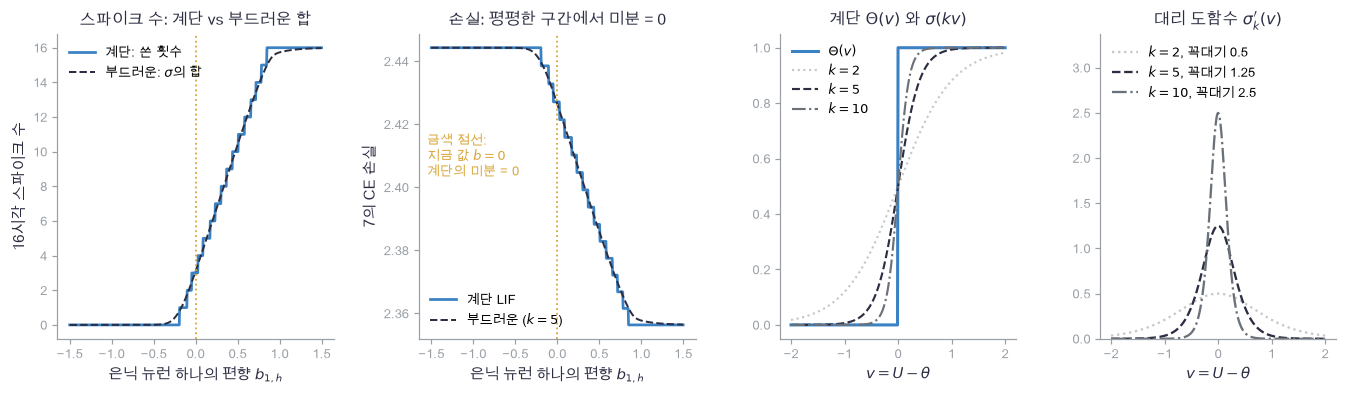

In [29]:
plot_step_vs_smooth(land_bias[:601], land_count[:601], land_soft[:601], land_loss_step[:601], land_loss_soft[:601],
                    land_T, land_k, surr_v, surr_step, surr_sigma, surr_deriv, surr_ks)

🔍 **확인** · 왼쪽 두 그림에서 계단 LIF(파랑)의 스파이크 수와 손실은 평평한 구간이 이어지다 한 칸씩 뛰는 계단입니다. 위 출력처럼 편향 601개를 훑어도 손실은 17가지 값(스파이크 수 0–16에 하나씩)만 갖고, 지금 값 $b=0$(금색 점선, 스파이크 3개)에서 계단 모델의 중심차분은 정확히 0입니다. 부드러운 LIF(검은 점선)는 같은 계단을 매끈하게 따라가며 $b=0$에서 기울기 −0.0797을 줍니다. 편향을 올리면 이 뉴런이 더 자주 쏘고 7의 손실이 준다는 방향 정보입니다.
오른쪽 두 그림은 $k$가 클수록 $\sigma(kv)$가 계단에 가까워지고, 그 도함수 $\sigma_k'$은 문턱 근처에 좁고 높게 몰리는 것을 보여 줍니다. 꼭대기는 $k/4$이고 넓이는 1에 가깝습니다(구간 $[-2,2]$만 재서 $k=2$는 0.964).

아래 표는 스칼라 뉴런 하나($T=3$, 전류 0.6씩)에서 손실 $L=S_1+S_2+S_3$(모든 $g_t=1$)의 BPTT를 마지막 시각부터 손으로 계산한 것입니다.

> **코드** · `for t in (2, 1, 0)`: Python 번호로 마지막 시각부터 거꾸로. 구현에서는 `reversed(range(T))`가 T−1, …, 0을 냅니다.

In [30]:
bp_beta, bp_theta, bp_k = 0.9, 1.0, 5.0
bp_U = np.zeros(3)                                     # (T,) = (3,): 스칼라 뉴런의 막전위
u, s = 0.0, 0.0
for t in range(3):
    u = bp_beta * u + 0.6 - bp_theta * s               # 전류 0.6씩 (1절 식)
    s = float(u >= bp_theta)
    bp_U[t] = u
bp_table = []                                          # 행: t = 3, 2, 1 · 열: g_t, −θdU_{t+1}, dS_t, σ_k'(U_t − θ), βdU_{t+1}, dU_t
dU_next = 0.0                                          # dU_4 = 0: 마지막 시각 뒤에는 막전위가 없음
for t in (2, 1, 0):                                    # 마지막 시각부터 거꾸로
    reset = 0.0 - bp_theta * dU_next                   # S_t가 U_{t+1}의 리셋 항 −θS_t로 쓰인 몫 (0.0 −: t = 3에서 −0.0 표시를 피함)
    dS_t = 1.0 + reset                                 # dS_t = g_t − θdU_{t+1}, g_t = 1
    g = 1 / (1 + np.exp(-bp_k * (bp_U[t] - bp_theta)))
    surr = bp_k * g * (1 - g)                          # σ_k'(U_t − θ)
    leak = bp_beta * dU_next                           # U_t가 U_{t+1} = βU_t + … 로 쓰인 몫
    dU = dS_t * surr + leak                            # dU_t
    bp_table.append([1.0, reset, dS_t, surr, leak, dU])
    dU_next = dU
print("U_t:", bp_U, "· 스파이크:", (bp_U >= 1).astype(int))
print("dU_3, dU_2, dU_1 =", np.array([row[5] for row in bp_table]))

U_t: [0.6   1.14  0.626] · 스파이크: [0 1 0]
dU_3, dU_2, dU_1 = [0.5785 0.9879 0.8955]


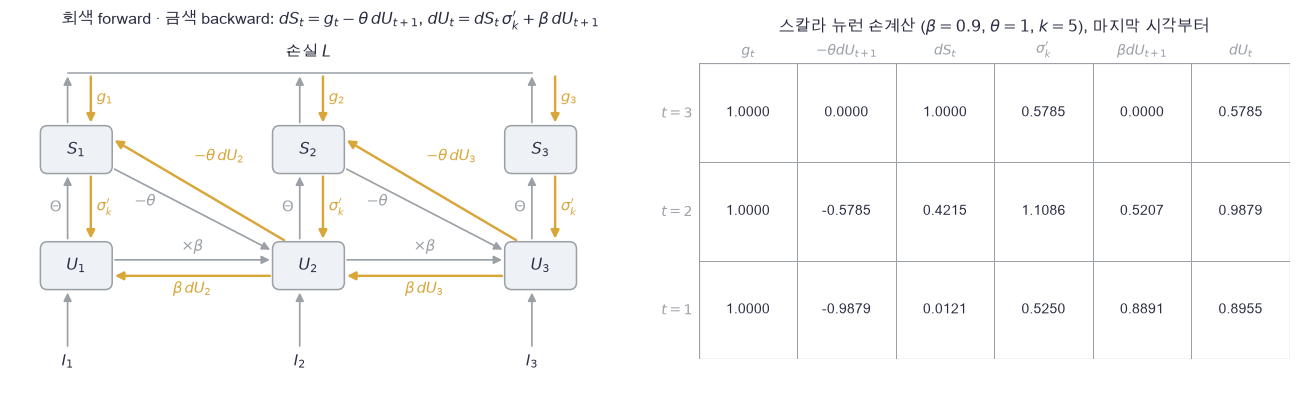

In [31]:
plot_lif_bptt(np.array(bp_table), ["$t=3$", "$t=2$", "$t=1$"],
              ["$g_t$", "$-\\theta dU_{t+1}$", "$dS_t$", "$\\sigma_k'$", "$\\beta dU_{t+1}$", "$dU_t$"], bp_beta, bp_theta, bp_k)

🔍 **확인** · 도식에서 $U_t$로 들어오는 금색 화살표는 두 개입니다. 위의 $S_t$에서 대리 도함수를 곱해 내려오는 것과, 오른쪽 $U_{t+1}$에서 $\beta$를 곱해 돌아오는 것입니다. $S_t$로도 금색 화살표 두 개가 들어옵니다. 손실에서 온 $g_t$와, $U_{t+1}$에서 리셋 경로를 거슬러 온 $-\theta\,dU_{t+1}$입니다. 06번 RNN에 없던 것이 이 리셋 경로입니다.
표에서 $t=3$은 미래가 없어 $dS_3=g_3=1$이고, $t=2$부터는 $-\theta\,dU_{t+1}$이 음수라 $dS_t$가 1보다 작아집니다. "지금 쏘면 다음 시각의 막전위가 $\theta$만큼 깎인다"는 효과가 기울기에 들어간 것입니다. $t=2$는 막전위 1.14가 문턱에 가까워 $\sigma_k'$이 크고, $t=1$·$t=3$(0.6, 0.626)은 문턱에서 멀어 작습니다.

아래 구현은 이 계산을 배치·다차원으로 쓰고, 검산에서 부드러운 LIF의 중심차분과 위 표를 대조합니다.

> **코드** · `1 / (1 + np.exp(-v))`: sigmoid(03번 3절). 큰 음수 `v`에서 `np.exp`가 넘칠 수 있지만 이 노트북의 막전위 범위에서는 문제없습니다.

In [32]:
def sigmoid(v):
    """σ(v) = 1/(1 + e^(−v)) (03번 3절). v: 배열 → 같은 모양."""
    return 1 / (1 + np.exp(-v))


def surrogate_grad(v, k):
    """대리 도함수 σ_k'(v) = k σ(kv)(1 − σ(kv)). 계단 Θ(v)의 도함수 자리에 씁니다. v: 배열 (U − θ), k: 가파름 → 같은 모양."""
    g = sigmoid(k * v)
    return k * g * (1 - g)

In [33]:
def lif_forward_smooth(I, beta, theta, k):
    """검산용 부드러운 LIF: lif_forward(1절)와 같고 스파이크만 S_t = σ(k(U_t − θ)). 리셋 항 −θS_{t−1}도 이 실수 S를 씁니다.
    I: (N, T, H), beta·theta·k: 숫자 → (U: (N, T, H), S: (N, T, H) 0과 1 사이 실수)."""
    N, T, H = I.shape
    U = np.zeros((N, T, H))
    S = np.zeros((N, T, H))
    u = np.zeros((N, H))
    s = np.zeros((N, H))
    for t in range(T):
        u = beta * u + I[:, t] - theta * s                 # lif_forward와 같은 줄
        s = sigmoid(k * (u - theta))                       # 다른 줄은 이것 하나: 계단 대신 σ
        U[:, t] = u
        S[:, t] = s
    return U, S

In [34]:
def lif_backward(dS, U, beta, theta, k):
    """LIF BPTT: 마지막 시각부터 dS_t = g_t − θ dU_{t+1}, dU_t = dS_t ⊙ σ_k'(U_t − θ) + β dU_{t+1}, dI_t = dU_t (dU_{T+1} = 0).
    dS: (N, T, H) 손실이 스파이크에 직접 준 기울기 g_t, U: (N, T, H) forward의 막전위 → dI: (N, T, H)."""
    N, T, H = U.shape
    dI = np.zeros((N, T, H))
    dU_next = np.zeros((N, H))                                    # dU_{T+1} = 0
    for t in reversed(range(T)):                                  # T−1, …, 0 (수학의 T, …, 1)
        dS_t = dS[:, t] - theta * dU_next                         # (N, H): 직접 온 g_t + 리셋 항 −θS_t를 거쳐 온 몫
        dU = dS_t * surrogate_grad(U[:, t] - theta, k) + beta * dU_next   # (N, H): S_t를 거친 몫 + βU_t를 거친 몫
        dI[:, t] = dU                                             # U_t = … + I_t 이므로 그대로
        dU_next = dU
    return dI

In [35]:
def check_lif_backward(candidate):
    """부드러운 LIF로 T = 1과 T = 6(리셋 경로가 있음)에서 dI를 중심차분과 대조합니다. → 상대오차 사전."""
    # 쓰는 것: lif_forward_smooth (4절)
    rng = np.random.default_rng(40)
    errors = {}
    for T in [1, 6]:
        I = rng.normal(size=(2, T, 3)) * 0.8 + 0.5          # (N, T, H): 문턱 근처를 오가는 전류
        G = rng.normal(size=(2, T, 3))                      # (N, T, H): 스파이크마다의 직접 기울기 g_t
        U, _ = lif_forward_smooth(I, 0.8, 1.0, 4.0)
        dI = candidate(G, U, 0.8, 1.0, 4.0)

        def scalar():
            """검사기용: 스칼라 L = Σ S ⊙ G (부드러운 LIF). 인자 없이 이번 설정의 I, G를 씁니다."""
            return float(np.sum(lif_forward_smooth(I, 0.8, 1.0, 4.0)[1] * G))

        error = rel_error(dI, numerical_gradient(scalar, I))
        assert np.isfinite(error), f"T={T}: 상대오차가 유한해야 합니다"
        assert error < 1e-6, f"T={T}: 상대오차 {error:.2e}는 1e−6 아래여야 합니다"
        errors[f"T{T}"] = error
    return errors

In [36]:
# 쓰는 것: bp_U, bp_table (4절 손계산 셀)
lif_errors = check_lif_backward(lif_backward)
print("부드러운 LIF의 dI 상대오차:", {key: f"{value:.1e}" for key, value in lif_errors.items()})
bp_dI = lif_backward(np.ones((1, 3, 1)), bp_U.reshape(1, 3, 1), 0.9, 1.0, 5.0)   # 스칼라 예제, g_t = 1
np.testing.assert_allclose(bp_dI.ravel()[::-1], [row[5] for row in bp_table])     # 검산: dU_t = 표. 표는 t = 3, 2, 1 순서라 뒤집어 비교
print("스칼라 예제의 dU_t (t = 1, 2, 3):", bp_dI.ravel(), "· 손계산 표와 같습니다.")

부드러운 LIF의 dI 상대오차: {'T1': '1.3e-10', 'T6': '1.9e-10'}
스칼라 예제의 dU_t (t = 1, 2, 3): [0.8955 0.9879 0.5785] · 손계산 표와 같습니다.


In [37]:
# 쓰는 것: lif_forward (1절) · lif_backward (4절)
step_I = np.random.default_rng(41).normal(size=(2, 6, 3)) * 0.8 + 0.5            # (2, 6, 3): 계단 LIF에 넣을 전류
step_G = np.random.default_rng(42).normal(size=(2, 6, 3))


def step_scalar():
    """검사기용: 계단 LIF의 L = Σ S ⊙ G. 인자 없이 step_I, step_G를 씁니다."""
    return float(np.sum(lif_forward(step_I, 0.8, 1.0)[1] * step_G))


step_numeric = numerical_gradient(step_scalar, step_I)
step_U, step_S = lif_forward(step_I, 0.8, 1.0)
step_surrogate = lif_backward(step_G, step_U, 0.8, 1.0, 4.0)
assert np.all(step_numeric == 0), "계단 LIF의 중심차분은 모두 0이어야 합니다 (문턱에 정확히 걸린 막전위가 없을 때)"
print(f"계단 LIF: 스파이크 {step_S.sum():.0f}개 · 중심차분이 0이 아닌 원소 {np.count_nonzero(step_numeric)}개 · 대리 도함수 기울기가 0이 아닌 원소 {np.count_nonzero(step_surrogate)}개 / {step_I.size}")

계단 LIF: 스파이크 13개 · 중심차분이 0이 아닌 원소 0개 · 대리 도함수 기울기가 0이 아닌 원소 36개 / 36


🔍 **확인** · 부드러운 LIF에서 $T=1$(리셋 경로 없음)과 $T=6$(리셋 경로 있음) 모두 상대오차가 $10^{-6}$ 아래이고, 스칼라 예제의 $dU_t$도 손계산 표와 같습니다. 같은 `lif_backward`를 계단 LIF의 막전위에 붙이면, 중심차분은 36개 원소가 모두 0인데 대리 도함수 기울기는 모두 0이 아닙니다. 계단 모델만으로는 학습할 신호가 없고, 대리 도함수가 그 신호를 만듭니다.
대리 도함수 기울기는 계단 모델의 "진짜" 도함수가 아니라 부드러운 모델의 도함수를 빌린 **근사**입니다. 그래도 방향이 쓸 만한지는 5절의 실제 학습으로 확인합니다.

### ✏️ 연습 4 · 대리 도함수 한 줄

`v` = 막전위 − 문턱 배열과 가파름 `k`에서 대리 도함수 $\sigma_k'(v)=k\,\sigma(kv)(1-\sigma(kv))$를 돌려주는 한 줄을 채우세요. `g` $=\sigma(kv)$는 써 두었습니다. 검사는 꼭대기 $k/4$, 넓이 1, $\sigma(kv)$를 중심차분한 값, 그리고 4절의 `surrogate_grad`로 합니다.

In [38]:
def exercise_surrogate(v, k):
    """연습 4: 대리 도함수 σ_k'(v) = k σ(kv)(1 − σ(kv)). v: 배열 (U − θ), k: 가파름 → v와 같은 모양."""
    g = 1 / (1 + np.exp(-k * v))                     # σ(kv)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: d = k · g · (1 − g) (모양은 v와 같음)
    ### 힌트: 4절 surrogate_grad의 return 줄입니다. 03번 3절 sigmoid 도함수 σ(1 − σ)에 안쪽 미분 k가 곱해집니다.
    raise NotImplementedError
    return d

In [39]:
def check_surrogate(candidate):
    """꼭대기 k/4, 넓이 1, σ(kv)의 중심차분, 4절 surrogate_grad로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: surrogate_grad (4절) · surr_v (4절 곡선 셀)
    np.testing.assert_allclose(candidate(np.array([0.]), 5.0), [1.25])                 # 검산: 손계산 5 · 0.5 · 0.5
    np.testing.assert_allclose(candidate(np.array([0.]), 2.0), [0.5])                  # 검산: 꼭대기 k/4
    v = np.linspace(-30, 30, 60001)
    area = np.trapezoid(candidate(v, 5.0), v)
    np.testing.assert_allclose(area, 1.0, atol=1e-6)                                    # 검산: 넓이 = 계단이 뛰는 크기 1
    eps = 1e-6
    numeric = (1 / (1 + np.exp(-5.0 * (surr_v + eps))) - 1 / (1 + np.exp(-5.0 * (surr_v - eps)))) / (2 * eps)
    np.testing.assert_allclose(candidate(surr_v, 5.0), numeric, atol=1e-6)             # 검산: σ(5v)를 중심차분한 값
    np.testing.assert_allclose(candidate(surr_v, 10.0), surrogate_grad(surr_v, 10.0))  # 검산: 4절 surrogate_grad와 같음
    print("대리 도함수: 꼭대기 k/4·넓이 1·중심차분과 일치합니다.")

run_check(check_surrogate, exercise_surrogate, hint="d = k * g * (1 - g)")

☐ exercise_surrogate: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: d = k * g * (1 - g)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
d = k * g * (1 - g)
```

</details>

## 🔑 5. 완성 실험: 스파이크로 부호화한 실제 MNIST 분류

**이 절에서 가져갈 것:** 05b번 3절의 학습 루프(에폭마다 섞기 → forward → CE → backward → Adam)에서 바뀌는 것은 세 가지입니다. 배치마다 이미지를 새로 부호화하고(2절), forward는 계단 LIF(3절), backward는 대리 도함수 BPTT(4절)를 씁니다. 읽기층의 기울기는 스파이크 수(3절) $C=\sum_tS_t$로 $dW_2=\frac1TC^\top G$입니다. 학습 뒤 추론 시각 수 $T$를 줄이면 덧셈 횟수는 $T$에 비례해 줄고 정확도는 조금만 떨어집니다.

05b번은 LeNet을 실제 MNIST 20,000장으로 학습했습니다. 같은 20,000장과 같은 검증·test 분할에서, 이번에는 이미지를 16시각의 스파이크로 바꿔 은닉 LIF 뉴런 128개와 시간 평균 읽기층으로 분류합니다. 은닉 뉴런이 하는 일은 1절의 물통입니다. 켜진 화소들의 가중치로 물이 차고, 눈금을 넘을 때만 "딸깍"을 냅니다. 무엇을 학습하나요? 어느 화소가 어느 물통에 얼마를 붓고 퍼낼지($W_1$), 그리고 각 물통의 "딸깍" 횟수를 숫자별 점수로 어떻게 합칠지($W_2$)입니다.

> **용어**
>
> - **에폭(epoch)·미니배치**(01b번 3절): 학습 집합을 섞어 $B$장씩 끊어 한 번씩 다 쓰는 단위. 20,000장을 128장씩이면 $\lceil20000/128\rceil=157$스텝입니다.
> - **Adam**(04번 6절): 기울기의 1·2차 이동평균으로 파라미터마다 보폭을 맞추는 optimizer. 학습률 0.002.

읽기층 $\mathrm{logits}=\frac1TCW_2+b_2$의 backward는 03번 5절의 선형층 세 식에 $1/T$만 붙습니다. $G=\partial L/\partial\,\mathrm{logits}=(P-Y)/B$ $(B,K)$는 02번 8절의 softmax CE 기울기입니다.

$$dW_2=\frac1T\,C^\top G,\qquad db_2=\sum_nG_n,\qquad g_t=\frac{\partial L}{\partial S_t}=\frac1T\,GW_2^\top\ \ (\text{모든 시각에 같음}),$$
$$dI=\mathrm{lif\_backward}(g,\,U),\qquad dW_1=\sum_{n,t}\big(S^{in}_{n,t}\big)^\top dI_{n,t},\qquad db_1=\sum_{n,t}dI_{n,t}.$$

logit은 스파이크 수에 $W_2/T$를 곱한 것이므로 $W_2$의 기울기는 스파이크 수와 $G$의 곱이고, 각 시각의 스파이크로 돌아가는 기울기 $g_t$는 시각과 상관없이 $GW_2^\top/T$입니다. 이 $g_t$를 4절의 `lif_backward`에 넣어 전류의 기울기를 얻고, 03번의 $dW=X^\top dZ$를 표본과 시각 모두에 대해 더합니다.

| 설정 | 값 | 이유 |
|---|---|---|
| 은닉 $H$, 시각 $T$ | 128, 16 | 60초 실행 예산 안에서 3에폭 |
| $\beta$, $\theta$, $k$ | 0.9, 1, 5 | 1·4절과 같음 |
| 배치, 학습률, 에폭 | 128, 0.002, 3 | 05b번과 같은 Adam, 배치만 두 배 |
| 초기화 | $W_1\sim\mathcal N(0,2/784)$, $W_2\sim\mathcal N(0,1/128)$ | $W_1$은 04번 9절의 He 초기화, $W_2$는 분산 $1/H$ (ReLU가 없는 읽기층이라 2 대신 1) |

아래 첫 그림은 한 스텝의 forward·backward 흐름을 텐서 모양으로 그린 것이고, 둘째 그림은 같은 7이 에폭마다 다른 스파이크 열로 부호화되는 모습입니다.

> **코드**
>
> - `rate_encode(mnist_7_flat[None], epoch_T, rng_epochs)[0]`: 2절처럼 한 장을 배치 `(1, 784)`로 세워 부호화한 뒤 첫 장 `(16, 784)`. `code[0]`은 그 첫 시각 `(784,)`.
> - `np.count_nonzero(a != b)`: 두 0/1 프레임에서 값이 다른 화소 수.

In [40]:
snn_forward_blocks = [("배치 $X$", "(B, 784)"), ("rate coding", "$S^{in}$ (B, 16, 784)"), ("전류 $S^{in}W_1+b_1$", "$I$ (B, 16, 128)"),
                      ("계단 LIF", "$U, S$ (B, 16, 128)"), ("스파이크 수", "$C$ (B, 128)"), ("$CW_2/T+b_2$", "logits (B, 10)"),
                      ("softmax CE", "손실 1개")]
snn_backward_blocks = {"G": ("$G=(P-Y)/B$", "(B, 10)"),                                  # 아랫줄: 키 → (상자 안 수식, 아래 모양)
                       "readout": ("$dW_2=C^\\top G/T$\n$db_2=\\sum G$", "(128, 10), (10,)"),
                       "g": ("$g_t=GW_2^\\top/T$", "$g$ (B, 16, 128)"), "lif": ("lif_backward", "$dI$ (B, 16, 128)"),
                       "W1": ("$dW_1=\\sum S^{in\\top} dI$", "(784, 128)"), "b1": ("$db_1=\\sum dI$", "(128,)")}

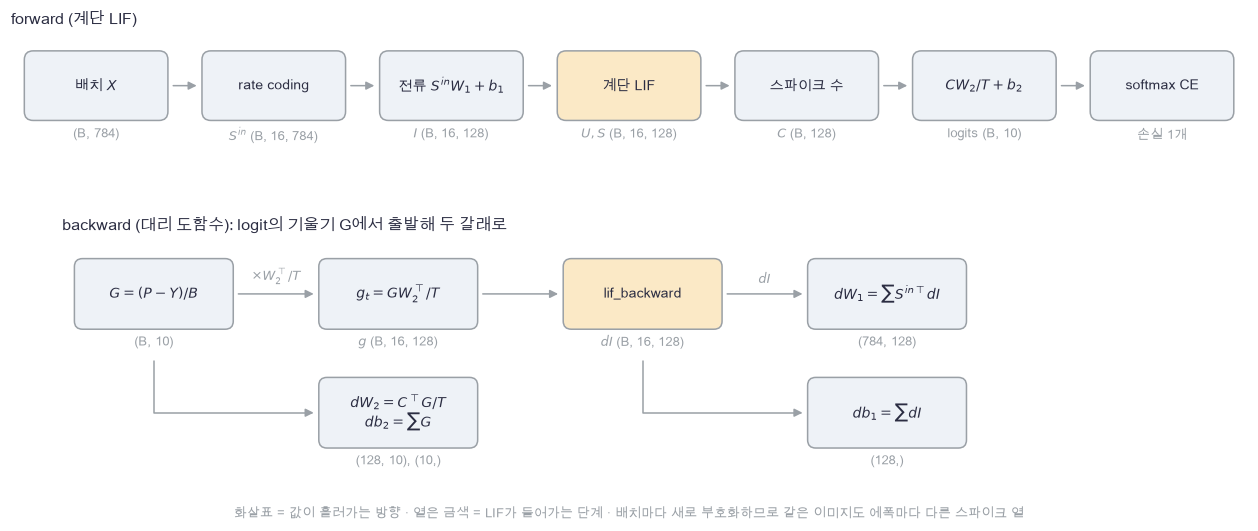

In [41]:
plot_snn_blocks(snn_forward_blocks, snn_backward_blocks)

In [42]:
# 쓰는 것: mnist_7_flat (📎 데이터 셀) · rate_encode (2절)
rng_epochs = np.random.default_rng(55)
epoch_T = 16
epoch_codes = [rate_encode(mnist_7_flat[None], epoch_T, rng_epochs)[0] for _ in range(3)]   # 3개의 (16, 784): 에폭 1·2·3의 부호화
epoch_frames = [code[0] for code in epoch_codes]                                     # 첫 시각 프레임 (784,)
epoch_means = [code.mean(axis=0) for code in epoch_codes]                            # 16시각 평균 (784,)
epoch_diff = [np.count_nonzero(epoch_frames[0] != frame) for frame in epoch_frames[1:]]
epoch_expected = np.sum(2 * mnist_7_flat * (1 - mnist_7_flat))                         # 두 프레임에서 다른 화소 수의 기댓값 Σ_d 2x_d(1 − x_d)
print("에폭 1과 첫 프레임이 다른 화소 수: 에폭 2", epoch_diff[0], "· 에폭 3", epoch_diff[1], f"· 기댓값 {epoch_expected:.1f}",
      "· 16시각 평균의 차이 최대", np.abs(epoch_means[0] - epoch_means[1]).max())

에폭 1과 첫 프레임이 다른 화소 수: 에폭 2 25 · 에폭 3 23 · 기댓값 20.7 · 16시각 평균의 차이 최대 0.375


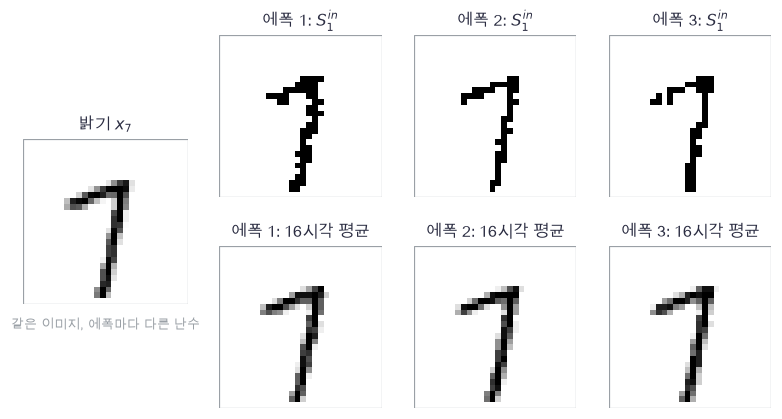

In [43]:
plot_epoch_encodings(mnist_7, epoch_frames, epoch_means, [1, 2, 3], epoch_T)

🔍 **확인** · 윗줄 forward에서 모양이 $(B, 784)$ → $(B, 16, 784)$ → $(B, 16, 128)$로 시간 축이 생겼다가, 스파이크 수에서 시간 축이 사라지고 logit $(B, 10)$이 됩니다. 아랫줄 backward는 logit의 기울기 $G$에서 출발해 두 갈래로 나뉩니다(화살표는 값이 흘러가는 방향). 한 갈래는 스파이크 수 $C$와 곱해 $dW_2$, 배치 축으로 더해 $db_2$가 되고, 다른 갈래는 $W_2^\top/T$를 곱해 모든 시각에 같은 $g_t$가 됩니다. $g_t$는 `lif_backward`(옅은 금색)를 지나 시각마다 다른 $dI$가 되고, 그 $dI$에서 $W_1$과 $b_1$의 기울기가 따로 나옵니다.
에폭 그림에서 같은 7이라도 첫 프레임이 에폭 1과 에폭 2에서 25화소, 에폭 3에서 23화소 다르고(위 출력), 에폭 1과 2의 16시각 평균도 화소 하나에서 최대 0.375만큼 다릅니다. 밝기 $x$인 화소가 두 번의 부호화에서 다를 확률은 $2x(1-x)$라서, 진한 화소(2절 출력의 0.9 이상 23개)에서는 작고 $x=0.5$ 근처의 옅은 화소에서 가장 큽니다. 이 확률을 잉크 화소 83개에 걸쳐 더한 기댓값 20.7개가 위 출력의 25개·23개와 같은 크기입니다. 학습은 이 흔들림을 견디는 가중치를 찾아야 합니다.

아래 셀은 05b번 3절의 함수 둘(`ce_loss`, `adam_update`)을 다시 적고, 이 노트북의 초기화·backward·학습 루프를 정의합니다.

> **코드**
>
> - `np.repeat(g[:, None, :], T, axis=1)`: `(N, H)`를 `(N, 1, H)`로 세운 뒤 시각 축으로 T번 복제해 `(N, T, H)`. `snn_backward`에서 모든 시각에 같은 $g_t$를 만듭니다.
> - `Sin.reshape(N * T, D)`: 표본과 시각을 한 축으로 펴서 03번의 `X.T @ dZ` 한 번으로 두 축의 합 $\sum_{n,t}$을 계산합니다.

In [44]:
def init_snn(hidden=128, seed=500):
    """SNN 파라미터 사전: W1 ~ N(0, 2/784) (He 초기화, 04번 9절), W2 ~ N(0, 1/H) (ReLU 없는 읽기층이라 분산 1/H), 편향 0.
    hidden: 은닉 LIF 뉴런 수 H, seed: 정수 → {"W1": (784, H), "b1": (H,), "W2": (H, 10), "b2": (10,)}."""
    rng_init = np.random.default_rng(seed)
    return {"W1": rng_init.normal(size=(784, hidden)) * np.sqrt(2 / 784), "b1": np.zeros(hidden),
            "W2": rng_init.normal(size=(hidden, 10)) * np.sqrt(1 / hidden), "b2": np.zeros(10)}

In [45]:
def ce_loss(logits, y):
    """softmax cross-entropy 평균과 logit 기울기 (02번 8절): J = −mean log P[n, y_n], G = (P − Y)/N.
    logits: (N, K), y: (N,) 정수 → (J: 숫자, G: (N, K))."""
    shifted = logits - logits.max(axis=1, keepdims=True)                 # 행마다 최댓값을 빼 지수가 넘치지 않게
    logp = shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))  # (N, K): log softmax
    loss = -logp[np.arange(len(y)), y].mean()                            # 정답 자리의 −log를 평균
    dlogits = np.exp(logp)                                               # (N, K): P
    dlogits[np.arange(len(y)), y] -= 1                                   # 정답 자리만 1을 빼면 P − Y
    return loss, dlogits / len(y)

In [46]:
def adam_update(p, grads, state, step, lr=0.002):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p를 제자리에서 바꾸고 state의 (m, v)를 갱신합니다.
    p, grads: 같은 키의 사전, state: 키 → (m, v), step: 1부터 세는 스텝 수, lr: 학습률."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                                # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2                       # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)

In [47]:
def snn_backward(dlogits, cache, p, beta, theta, k):
    """3절 모델의 backward. 읽기층: dW2 = (1/T) Cᵀ G, db2 = Σ_n G, 스파이크로 g_t = (1/T) G W2ᵀ (모든 시각에 같음).
    LIF: 4절 lif_backward. 입력층: dW1 = Σ_{n,t} S^in_{n,t}ᵀ dI_{n,t}, db1 = Σ_{n,t} dI_{n,t}.
    dlogits: (N, K) = G, cache: snn_forward의 (Sin, U, S), p: 파라미터 사전 → grads: p와 같은 키·모양."""
    # 쓰는 것: lif_backward (4절)
    Sin, U, S = cache
    N, T, D = Sin.shape
    H = U.shape[2]
    counts = S.sum(axis=1)                                             # (N, H): 스파이크 수 C
    grads = {"W2": counts.T @ dlogits / T, "b2": dlogits.sum(axis=0)}  # 1. 읽기층 (03번 5절의 선형층 식에 1/T)
    g = (dlogits @ p["W2"].T) / T                                      # (N, H): 한 시각의 스파이크로 가는 기울기
    dS = np.repeat(g[:, None, :], T, axis=1)                           # 2. (N, T, H): 모든 시각에 같은 g_t
    dI = lif_backward(dS, U, beta, theta, k)                           # 3. (N, T, H): LIF를 시간 역순으로
    grads["W1"] = Sin.reshape(N * T, D).T @ dI.reshape(N * T, H)       # 4. (D, H): 표본·시각을 한 축으로 펴서 Σ Sᵀ dI
    grads["b1"] = dI.sum(axis=(0, 1))                                  # (H,)
    return grads

🔍 **확인** · **전체 모델의 검산.** 4절처럼 계단 LIF 자리에 부드러운 LIF를 넣으면 `snn_backward`가 정확한 도함수여야 합니다. 3절 `snn_forward`의 `lif` 인자에 $k=4$인 부드러운 LIF를 넘기고, 입력 스파이크 $(3, 4, 6)$·은닉 5·클래스 3인 작은 모델에서 네 파라미터를 모두 중심차분과 대조합니다. 학습에 쓰는 `snn_backward`가 맞는지 확인하는 유일한 검산입니다.

In [48]:
# 쓰는 것: snn_forward (3절) · lif_forward_smooth (4절)
def smooth_lif(I, beta, theta):
    """검산용: k = 4인 부드러운 LIF (4절 lif_forward_smooth). snn_forward의 lif 인자 자리에 넣습니다."""
    return lif_forward_smooth(I, beta, theta, 4.0)


rng_model = np.random.default_rng(56)
model_Sin = (rng_model.random((3, 4, 6)) < 0.5).astype(float)          # (N, T, D) = (3, 4, 6): 0/1 입력
model_y = np.array([0, 2, 1])
model_p = {"W1": rng_model.normal(size=(6, 5)) * 0.8, "b1": rng_model.normal(size=5) * 0.3 + 0.4,
           "W2": rng_model.normal(size=(5, 3)), "b2": rng_model.normal(size=3) * 0.1}
model_logits, model_cache = snn_forward(model_Sin, model_p, 0.8, 1.0, lif=smooth_lif)
model_loss, model_dlogits = ce_loss(model_logits, model_y)
model_grads = snn_backward(model_dlogits, model_cache, model_p, 0.8, 1.0, 4.0)
print("작은 모델: logits", model_logits.shape, "· CE", round(float(model_loss), 4), "· 기울기 모양",
      {key: value.shape for key, value in model_grads.items()})

작은 모델: logits (3, 3) · CE 1.2964 · 기울기 모양 {'W2': (5, 3), 'b2': (3,), 'W1': (6, 5), 'b1': (5,)}


In [49]:
def model_scalar():
    """검사기용: 부드러운 LIF 모델의 CE. 인자 없이 model_Sin, model_y, model_p를 씁니다."""
    # 쓰는 것: snn_forward (3절) · ce_loss (5절) · smooth_lif, model_Sin, model_y, model_p (5절 검산 셀)
    return float(ce_loss(snn_forward(model_Sin, model_p, 0.8, 1.0, lif=smooth_lif)[0], model_y)[0])


model_errors = {key: rel_error(model_grads[key], numerical_gradient(model_scalar, model_p[key])) for key in model_p}
assert max(model_errors.values()) < 1e-6, "부드러운 LIF 모델의 네 파라미터 기울기 상대오차가 1e−6 아래여야 합니다"
print("전체 모델의 상대오차:", {key: f"{value:.1e}" for key, value in model_errors.items()})

전체 모델의 상대오차: {'W1': '1.7e-09', 'b1': '1.7e-09', 'W2': '6.7e-10', 'b2': '6.6e-10'}


🔍 **확인** · 읽기층·LIF·입력층을 이은 전체 backward가 부드러운 모델에서 네 파라미터 모두 중심차분과 $10^{-6}$ 아래로 맞습니다. 이제 같은 `snn_backward`를 계단 LIF의 캐시에 붙여 학습합니다.

아래는 검증·test 수천 장을 끊어 forward만 하는 함수, 정확도, 그리고 학습 루프입니다. 학습 루프는 05b번 3절의 `train_lenet`에서 부호화 한 줄이 늘었고, 에폭 끝에 검증 정확도와 함께 은닉 발화율을 기록합니다.

> **코드**
>
> - `for start in range(0, len(X), chunk)`: 10,000장을 한 번에 부호화하면 `(10000, 16, 784)`가 약 1GB라 500장씩 끊어 forward만 합니다. `np.concatenate(pieces)`로 다시 이어 붙입니다.
> - `rng_train.permutation(len(X))`: 0부터 N−1까지를 한 번씩 무작위 순서로 늘어놓은 `(N,)`. `order[start:start + batch_size]`로 잘라 에폭마다 다른 배치를 만듭니다(05b번 3절).

In [50]:
def predict_snn(X, p, T, beta, theta, rng, chunk=500):
    """수천 장을 chunk장씩 부호화해 forward만 (계단 LIF). X: (N, 784), p: 파라미터 사전, T: 시각 수, rng: 부호화 난수
    → (logits: (N, 10), in_spikes: (N,) 장마다 입력 스파이크 수, hidden_spikes: (N,) 장마다 은닉 스파이크 수)."""
    # 쓰는 것: rate_encode (2절) · snn_forward (3절)
    logits, in_spikes, hidden_spikes = [], [], []
    for start in range(0, len(X), chunk):
        Sin = rate_encode(X[start:start + chunk], T, rng)            # (chunk, T, 784)
        chunk_logits, (_, _, S) = snn_forward(Sin, p, beta, theta)
        logits.append(chunk_logits)
        in_spikes.append(Sin.sum(axis=(1, 2)))                        # (chunk,)
        hidden_spikes.append(S.sum(axis=(1, 2)))                      # (chunk,)
    return np.concatenate(logits), np.concatenate(in_spikes), np.concatenate(hidden_spikes)


def accuracy(logits, y):
    """정확도: logit이 가장 큰 숫자가 정답과 같은 비율. logits: (N, 10), y: (N,) → 숫자."""
    return float(np.mean(logits.argmax(axis=1) == y))

In [51]:
def train_snn(p, X, y, X_valid, y_valid, epochs, batch_size, lr, T, beta, theta, k, seed=501):
    """미니배치 Adam 학습 (05b번 3절의 루프). 스텝마다 부호화 → snn_forward(계단) → CE → snn_backward(대리 도함수) → Adam.
    p: 파라미터 사전(제자리에서 갱신), X: (N, 784), y: (N,), X_valid·y_valid: 검증 집합
    → history: {"loss": 스텝별 배치 CE, "valid_acc"·"valid_rate": 에폭별 검증 정확도·은닉 발화율, "epoch_steps": 에폭이 끝난 스텝}."""
    # 쓰는 것: rate_encode (2절) · snn_forward (3절) · ce_loss, adam_update, snn_backward, predict_snn, accuracy (5절)
    state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}   # Adam 상태 (m, v)
    rng_train = np.random.default_rng(seed)
    history = {"loss": [], "valid_acc": [], "valid_rate": [], "epoch_steps": []}
    step = 0
    for epoch in range(epochs):
        order = rng_train.permutation(len(X))
        for start in range(0, len(X), batch_size):
            idx = order[start:start + batch_size]                     # 1. 이번 배치의 번호 (B,)
            Sin = rate_encode(X[idx], T, rng_train)                   # 2. 배치마다 새로 부호화 (B, T, 784)
            logits, cache = snn_forward(Sin, p, beta, theta)         # 3. forward: 계단 LIF
            loss, dlogits = ce_loss(logits, y[idx])                   # 4. 손실과 logit 기울기 G
            grads = snn_backward(dlogits, cache, p, beta, theta, k)   # 5. backward: 대리 도함수
            step += 1
            adam_update(p, grads, state, step, lr)                    # 6. 갱신 (step은 1부터)
            history["loss"].append(loss)
        valid_logits, _, valid_hidden = predict_snn(X_valid, p, T, beta, theta, rng_train)
        history["valid_acc"].append(accuracy(valid_logits, y_valid))
        history["valid_rate"].append(float(valid_hidden.mean() / (T * p["b1"].size)))   # 발화율 = 장당 은닉 스파이크 수 / (T·H)
        history["epoch_steps"].append(step)
        print(f"에폭 {epoch + 1}: 스텝 {step} · 마지막 배치 CE {loss:.3f} · 검증 정확도 {history['valid_acc'][-1]:.4f} · 은닉 발화율 {history['valid_rate'][-1]:.3f}")
    return history

In [52]:
# 쓰는 것: mnist_X_train, mnist_y_train, mnist_X_valid, mnist_y_valid (📎 데이터 셀) · init_snn, train_snn (5절)
SNN_T, SNN_BETA, SNN_THETA, SNN_K = 16, 0.9, 1.0, 5.0                 # 시각 수, 누설, 문턱, 대리 도함수 가파름
snn_p = init_snn(128, 500)
snn_W1_before = snn_p["W1"].copy()                                     # (784, 128): 학습 전 가중치 (비교용 복사본)
t_start = time.perf_counter()
snn_history = train_snn(snn_p, mnist_X_train, mnist_y_train, mnist_X_valid, mnist_y_valid,
                        epochs=3, batch_size=128, lr=0.002, T=SNN_T, beta=SNN_BETA, theta=SNN_THETA, k=SNN_K)
train_seconds = time.perf_counter() - t_start
assert len(snn_history["loss"]) == 3 * math.ceil(20000 / 128), "3에폭이면 스텝 수는 3 × ⌈20000/128⌉ = 471이어야 합니다"
assert snn_history["valid_acc"][-1] > 0.9, "스파이크만으로도 검증 정확도가 90%는 넘어야 합니다"
print(f"학습 {train_seconds:.1f}초 · 검증 정확도 {snn_history['valid_acc'][-1]:.4f} (n=2000) · W1 변화 최대 {np.abs(snn_p['W1'] - snn_W1_before).max():.3f}")

에폭 1: 스텝 157 · 마지막 배치 CE 0.442 · 검증 정확도 0.9545 · 은닉 발화율 0.437


에폭 2: 스텝 314 · 마지막 배치 CE 0.224 · 검증 정확도 0.9690 · 은닉 발화율 0.434


에폭 3: 스텝 471 · 마지막 배치 CE 0.139 · 검증 정확도 0.9700 · 은닉 발화율 0.428
학습 7.8초 · 검증 정확도 0.9700 (n=2000) · W1 변화 최대 0.350


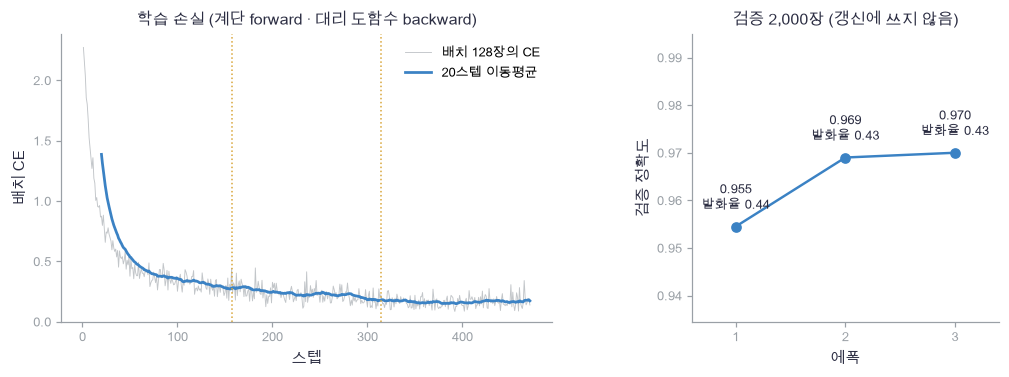

In [53]:
plot_training_result(snn_history["loss"], 20, snn_history["epoch_steps"], snn_history["valid_acc"], snn_history["valid_rate"], 128, len(mnist_X_valid))

🔍 **확인** · 배치 CE는 흔들리지만 이동평균은 첫 에폭 안에 크게 내려갑니다. 검증 정확도는 첫 에폭 끝에 이미 0.955이고 3에폭 뒤 0.970입니다. forward는 한 번도 부드러워진 적이 없는 계단 LIF인데도 대리 도함수 방향으로 가중치를 고치면 손실이 줄어듭니다. 은닉 발화율은 0.43–0.44로, 뉴런들이 16시각 중 평균 7번쯤 쏩니다. 발화를 줄이라는 목적이 없으니 드물게 쏠 이유도 없습니다.

아래는 학습·검증에 쓰지 않은 test 10,000장을 $T=16$으로 통과시켜 보고합니다. 05b번처럼 test는 이 셀에서 **한 번만** 봅니다. 이어서 검증 2,000장으로 뉴런별 발화율을 재고, 학습된 모델이 7과 1을 어떻게 보는지 봅니다.

> **코드**
>
> - `np.argsort(-rates)`: 발화율이 큰 순서의 뉴런 번호. `S[:, order]`는 래스터의 열을 그 순서로 다시 놓습니다.
> - `mnist_examples[1].reshape(1, 784)`: 고정 예시의 1 `(28, 28)`을 한 장짜리 배치 `(1, 784)`로 폅니다.

In [54]:
# 쓰는 것: mnist_X_test, mnist_y_test (📎 데이터 셀) · predict_snn, accuracy (5절) · snn_p, SNN_T, SNN_BETA, SNN_THETA (5절 학습 셀)
test_logits, test_in, test_hidden = predict_snn(mnist_X_test, snn_p, SNN_T, SNN_BETA, SNN_THETA, np.random.default_rng(502))
test_accuracy = accuracy(test_logits, mnist_y_test)
assert test_accuracy > 0.9, "test 정확도도 90%는 넘어야 합니다"
print(f"test 정확도 {test_accuracy:.4f} (n=10000) · 장당 입력 스파이크 {test_in.mean():.0f} · 은닉 스파이크 {test_hidden.mean():.0f} (발화율 {test_hidden.mean() / (SNN_T * 128):.3f})")

test 정확도 0.9460 (n=10000) · 장당 입력 스파이크 1662 · 은닉 스파이크 880 (발화율 0.430)


In [55]:
# 쓰는 것: mnist_X_valid (📎 데이터 셀) · rate_encode (2절) · snn_forward (3절) · snn_p, SNN_T, SNN_BETA, SNN_THETA (5절 학습 셀)
rng_rates = np.random.default_rng(503)
valid_counts = np.zeros(128)                                                                # (128,): 뉴런별 검증 스파이크 수
for start in range(0, 2000, 500):                                                           # 500장씩 (메모리)
    valid_S = snn_forward(rate_encode(mnist_X_valid[start:start + 500], SNN_T, rng_rates), snn_p, SNN_BETA, SNN_THETA)[1][2]
    valid_counts += valid_S.sum(axis=(0, 1))
valid_rates = valid_counts / (2000 * SNN_T)                                                 # (128,): 뉴런별 검증 발화율
rate_order = np.argsort(-valid_rates)                                                       # 발화율이 큰 순서
print(f"검증 발화율: 최소 {valid_rates.min():.3f} · 최대 {valid_rates.max():.3f} · 0.05 미만 뉴런 {np.sum(valid_rates < 0.05)}개")

검증 발화율: 최소 0.000 · 최대 0.819 · 0.05 미만 뉴런 5개


In [56]:
# 쓰는 것: mnist_examples, mnist_7_flat (📎 데이터 셀) · rate_encode (2절) · snn_forward (3절) · snn_p, SNN_T, SNN_BETA, SNN_THETA (5절 학습 셀)
trained_logits, (_, _, trained_S) = snn_forward(rate_encode(mnist_7_flat[None], SNN_T, np.random.default_rng(504)),
                                                snn_p, SNN_BETA, SNN_THETA)                 # 학습 뒤 7 한 장
one_logits, (_, _, one_S) = snn_forward(rate_encode(mnist_examples[1].reshape(1, 784), SNN_T, np.random.default_rng(505)),
                                        snn_p, SNN_BETA, SNN_THETA)                         # 같은 가중치로 1 한 장
count_7 = trained_S[0].sum(axis=0)                                                          # (128,): 7의 뉴런별 스파이크 수 C
count_1 = one_S[0].sum(axis=0)                                                              # (128,): 1의 뉴런별 스파이크 수
print(f"학습 뒤 7: 은닉 스파이크 {trained_S.sum():.0f}개 · 예측 {trained_logits.argmax()} · logit 7 = {trained_logits[0, 7]:.2f}, 다음으로 큰 logit {np.sort(trained_logits[0])[-2]:.2f}")
print(f"학습 뒤 1: 은닉 스파이크 {one_S.sum():.0f}개 · 예측 {one_logits.argmax()} · 7과 1에서 스파이크 수가 8번 이상 다른 뉴런 {np.sum(np.abs(count_7 - count_1) >= 8)}개 / 128")

학습 뒤 7: 은닉 스파이크 815개 · 예측 7 · logit 7 = 5.60, 다음으로 큰 logit 2.20
학습 뒤 1: 은닉 스파이크 886개 · 예측 1 · 7과 1에서 스파이크 수가 8번 이상 다른 뉴런 53개 / 128


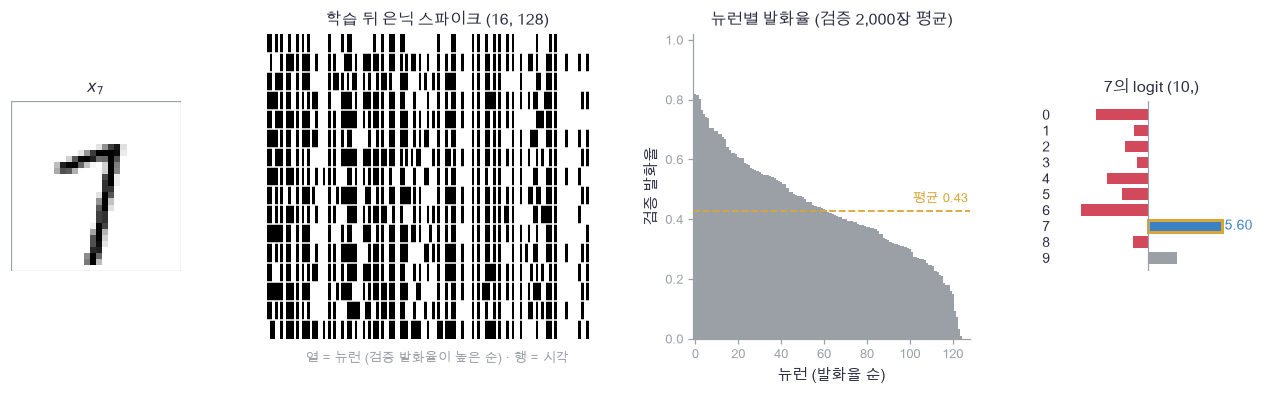

In [57]:
plot_trained_spikes(mnist_7, trained_S[0][:, rate_order], valid_rates[rate_order], trained_logits[0], 7, len(mnist_X_valid))

🔍 **확인** · test 정확도 0.946은 05b번 LeNet(합성곱 두 단, 0.980)보다 낮지만, 이미지를 0/1 스파이크로만 받는 은닉층 하나로 얻은 값입니다. 검증 정확도 0.970보다도 2%p 넘게 낮은데, 검증 2,000장은 학습 파일 맨 뒤의 한 덩어리라 test와 같은 성격의 표본이라는 보장이 없습니다. 그래서 이 차이를 과적합으로 바로 읽지 않습니다([15](../02_연결/15_experiments_evaluation.ipynb)번 1절: 어떤 새 사례에 대한 성능인지). 가운데 막대는 검증 2,000장에 걸쳐 평균낸 뉴런별 발화율로, 0.8 가까이 쏘는 뉴런부터 거의 쏘지 않는 뉴런(0.05 미만 5개)까지 퍼져 있습니다. 평균 발화율이 0에 가까운 뉴런은 검증 이미지 전체에서 쏜 횟수 자체가 적어, 점수에 보태는 몫도 평균적으로 작습니다. 다만 이 평균만으로는 뉴런이 숫자를 구별하는지 알 수 없습니다. 구별은 같은 뉴런이 **이미지마다** 다르게 쏘는 데서 나옵니다. 위 출력처럼 같은 가중치에서 7과 1의 스파이크 수가 8번 이상 다른 뉴런이 128개 중 53개이고, 이 스파이크 수 $C$의 차이가 $W_2/T$를 거쳐 점수 차이가 됩니다.
7의 래스터도 대체로 왼쪽(검증에서 자주 쏘는 뉴런) 열이 촘촘하고 오른쪽이 성깁니다. 이 뉴런별 스파이크 수에 $W_2/T$를 곱한 점수에서 7의 logit이 가장 큽니다.

이제 **같은 가중치**로 추론 시각 수 $T$만 1, 2, 4, 8, 16, 32로 바꿉니다. 설정을 바꿔 보는 실험이므로 test가 아니라 **검증 2,000장**으로 하고(15번 4절), 부호화 난수에 따른 흔들림을 보려고 seed 5개로 반복해 평균과 표준편차를 냅니다. 덧셈 횟수는 장당 (입력 스파이크 수)×128 + (은닉 스파이크 수)×10입니다.
같은 크기의 실수 MLP(784 → 128 → 10)는 0인 화소까지 모두 곱하면 $784\cdot128+128\cdot10=101{,}632$번이지만, 0인 화소를 건너뛰면 (0이 아닌 화소 수)×128 + 1,280번이면 됩니다(은닉 128개는 모두 곱한다고 본 상한). SNN의 입력 스파이크도 0인 화소에서는 나오지 않으므로 견줄 기준은 뒤의 것입니다.

> **코드** · `np.count_nonzero(mnist_X_valid, axis=1)`: 행(이미지)마다 0이 아닌 화소 수 `(2000,)`.

In [58]:
# 쓰는 것: mnist_X_valid, mnist_y_valid (📎 데이터 셀) · predict_snn, accuracy (5절) · snn_p, SNN_BETA, SNN_THETA (5절 학습 셀)
sweep_Ts = [1, 2, 4, 8, 16, 32]
sweep_seeds = [510, 511, 512, 513, 514]                                   # 부호화 난수 5가지
sweep_acc = np.zeros((len(sweep_seeds), len(sweep_Ts)))                  # (seed 수, T 수) = (5, 6): 검증 정확도
sweep_in = np.zeros((len(sweep_seeds), len(sweep_Ts)))                   # (5, 6): 장당 입력 스파이크 수
sweep_hidden = np.zeros((len(sweep_seeds), len(sweep_Ts)))               # (5, 6): 장당 은닉 스파이크 수
for a, seed in enumerate(sweep_seeds):
    for b, T in enumerate(sweep_Ts):
        logits, spikes_in, spikes_hidden = predict_snn(mnist_X_valid, snn_p, T, SNN_BETA, SNN_THETA, np.random.default_rng(seed))
        sweep_acc[a, b] = accuracy(logits, mnist_y_valid)
        sweep_in[a, b] = spikes_in.mean()
        sweep_hidden[a, b] = spikes_hidden.mean()
sweep_ops = sweep_in.mean(axis=0) * 128 + sweep_hidden.mean(axis=0) * 10   # (6,): 장당 시냅스 연산(덧셈) 수
np.testing.assert_allclose(sweep_in.mean(axis=0) / sweep_Ts, mnist_X_valid.sum(axis=1).mean(), rtol=0.01)   # 검산: 장당 입력 스파이크 기댓값 = T × 밝기 합 (2절)
print("seed별 검증 정확도 (행 = seed, 열 = T):")
print(sweep_acc)

seed별 검증 정확도 (행 = seed, 열 = T):
[[0.952  0.964  0.9685 0.9695 0.9685 0.969 ]
 [0.9525 0.965  0.9655 0.9685 0.969  0.9695]
 [0.9495 0.964  0.967  0.9675 0.968  0.969 ]
 [0.9515 0.96   0.9675 0.9665 0.9675 0.969 ]
 [0.9565 0.9645 0.9695 0.969  0.9685 0.9675]]


In [59]:
# 쓰는 것: mnist_X_valid (📎 데이터 셀) · sweep_Ts, sweep_acc, sweep_in, sweep_hidden, sweep_ops (5절 T 비교 셀)
dense_ops = 784 * 128 + 128 * 10                                          # 0까지 모두 곱하는 MLP의 곱셈 수
valid_nonzero = np.count_nonzero(mnist_X_valid, axis=1).mean()            # 장당 0이 아닌 화소 수
sparse_ops = valid_nonzero * 128 + 128 * 10                               # 0인 화소를 건너뛰는 MLP의 곱셈 수 (은닉 128개는 모두 곱한다고 본 상한)
hidden_share = sweep_hidden.mean(axis=0) * 10 / sweep_ops                 # (6,): 덧셈 중 은닉 스파이크(읽기층)의 몫
for b, T in enumerate(sweep_Ts):
    print(f"T = {T:2d}: 검증 정확도 {sweep_acc[:, b].mean():.4f} ± {sweep_acc[:, b].std():.4f} · 입력 스파이크 {sweep_in[:, b].mean():5.0f} · "
          f"은닉 스파이크 {sweep_hidden[:, b].mean():5.0f} · 덧셈 {sweep_ops[b]:8,.0f} (0까지 곱하는 MLP의 {sweep_ops[b] / dense_ops:.2f}배, "
          f"0을 건너뛰는 MLP의 {sweep_ops[b] / sparse_ops:.2f}배) · 은닉 몫 {hidden_share[b]:.1%}")
print(f"장당 0이 아닌 화소 {valid_nonzero:.1f}개 · 0을 건너뛰는 MLP의 곱셈 {sparse_ops:,.0f}번 · 0까지 곱하는 MLP {dense_ops:,}번")

T =  1: 검증 정확도 0.9524 ± 0.0023 · 입력 스파이크   103 · 은닉 스파이크    44 · 덧셈   13,676 (0까지 곱하는 MLP의 0.13배, 0을 건너뛰는 MLP의 0.66배) · 은닉 몫 3.2%
T =  2: 검증 정확도 0.9635 ± 0.0018 · 입력 스파이크   207 · 은닉 스파이크    99 · 덧셈   27,446 (0까지 곱하는 MLP의 0.27배, 0을 건너뛰는 MLP의 1.32배) · 은닉 몫 3.6%
T =  4: 검증 정확도 0.9676 ± 0.0014 · 입력 스파이크   413 · 은닉 스파이크   209 · 덧셈   55,012 (0까지 곱하는 MLP의 0.54배, 0을 건너뛰는 MLP의 2.65배) · 은닉 몫 3.8%
T =  8: 검증 정확도 0.9682 ± 0.0011 · 입력 스파이크   827 · 은닉 스파이크   431 · 덧셈  110,137 (0까지 곱하는 MLP의 1.08배, 0을 건너뛰는 MLP의 5.30배) · 은닉 몫 3.9%
T = 16: 검증 정확도 0.9683 ± 0.0005 · 입력 스파이크  1654 · 은닉 스파이크   876 · 덧셈  220,461 (0까지 곱하는 MLP의 2.17배, 0을 건너뛰는 MLP의 10.62배) · 은닉 몫 4.0%
T = 32: 검증 정확도 0.9688 ± 0.0007 · 입력 스파이크  3308 · 은닉 스파이크  1765 · 덧셈  441,027 (0까지 곱하는 MLP의 4.34배, 0을 건너뛰는 MLP의 21.24배) · 은닉 몫 4.0%
장당 0이 아닌 화소 152.2개 · 0을 건너뛰는 MLP의 곱셈 20,765번 · 0까지 곱하는 MLP 101,632번


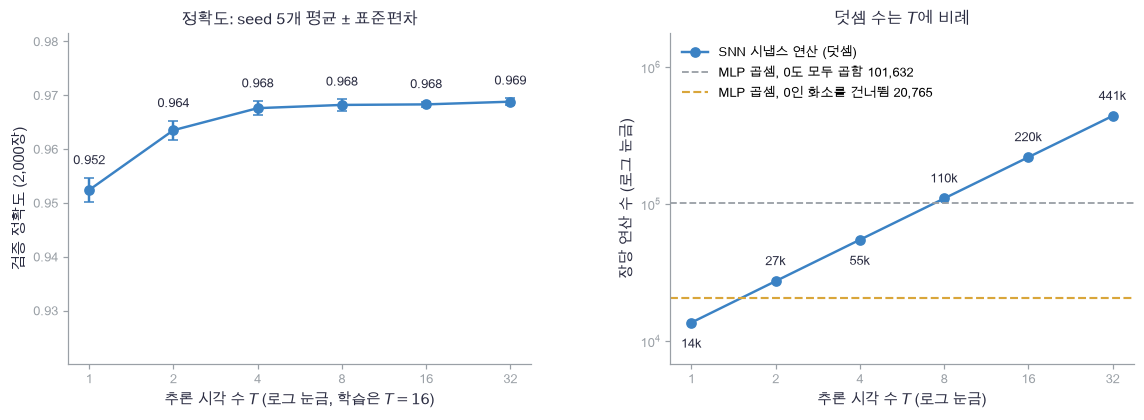

In [60]:
plot_time_steps(sweep_Ts, sweep_acc.mean(axis=0), sweep_acc.std(axis=0), sweep_ops, dense_ops, sparse_ops, SNN_T, len(mnist_X_valid), len(sweep_seeds))

🔍 **확인** · 같은 가중치에서 $T$를 16에서 4로 줄여도 검증 정확도는 평균 0.9683에서 0.9676으로 거의 그대로이고, $T=2$에서 0.9635, $T=1$(시각 하나, 입력도 은닉도 한 번씩만 0/1)에서 0.9524로 떨어집니다. $T=4$ 이후의 차이(가장 커도 0.0012)는 seed 사이의 표준편차(오차 막대, 0.0005–0.0014)와 비슷한 크기라 이 검증 2,000장으로는 구별하기 어렵습니다. 반면 덧셈 횟수는 $T$에 거의 정확히 비례해 한 칸마다 두 배가 됩니다. 시각 수 $T$가 정확도와 계산량을 **함께** 정합니다.
오른쪽의 두 기준선을 보면, 0까지 모두 곱하는 MLP(회색)에 견주면 $T=16$의 덧셈이 2.17배이고 $T=1$은 0.13배로 적어 보입니다. 하지만 0인 화소를 건너뛰는 MLP(금색, 장당 20,765번)에 견주면 $T=1$에서 0.66배, $T=2$에서 이미 1.32배, $T=16$에서는 10.62배입니다. 곱셈 대신 덧셈이라는 차이는 있지만, 이 모델이 0을 건너뛰는 같은 크기 MLP보다 연산 **횟수**가 적은 것은 $T=1$뿐입니다. 덧셈 한 번과 곱셈 한 번의 비용이나 전력은 하드웨어마다 달라 이 노트북은 횟수만 비교하고, SNN 쪽 횟수에는 누설 $\beta U$의 곱셈(장당 $T\cdot H$번, $T=16$이면 2,048번)이 빠져 있습니다.
덧셈의 대부분은 입력 스파이크 × 128입니다. 위 출력의 은닉 몫처럼 은닉 스파이크가 읽기층에서 쓰는 덧셈은 $T=16$에서 4.0%뿐이라, 은닉 발화율을 낮춰도 덧셈 수는 거의 줄지 않습니다. 이 rate coding에서 덧셈 수를 정하는 것은 $T$와 이미지의 밝기 합입니다.

📎 **같은 크기 MLP와 견주기.** 스파이크 대신 실수 이미지를 받는 ReLU MLP(784 → 128 → 10, 03번 4·5절)를 같은 배치 순서 규칙·Adam·3에폭으로 학습해 검증 정확도를 봅니다. 두 모델을 견주는 것도 설정 비교라서 test가 아니라 검증 집합으로 합니다. 초기화도 `init_snn`의 같은 모양을 씁니다.

In [61]:
def train_mlp(X, y, epochs, batch_size, lr, seed=500):
    """비교용 ReLU MLP 784 → 128 → 10 (03번 4·5절)을 train_snn과 같은 배치·Adam 설정으로 학습. X: (N, 784), y: (N,) → 파라미터 사전."""
    # 쓰는 것: init_snn, ce_loss, adam_update (5절)
    p = init_snn(128, seed)                                               # 같은 모양·같은 초기화
    state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}
    rng_mlp = np.random.default_rng(seed + 1)
    step = 0
    for epoch in range(epochs):
        order = rng_mlp.permutation(len(X))
        for start in range(0, len(X), batch_size):
            idx = order[start:start + batch_size]
            Z = X[idx] @ p["W1"] + p["b1"]                                # (B, 128)
            A = np.maximum(Z, 0)                                          # ReLU
            _, dlogits = ce_loss(A @ p["W2"] + p["b2"], y[idx])           # (B, 10)
            dZ = (dlogits @ p["W2"].T) * (Z > 0)                          # (B, 128): ReLU 도함수
            grads = {"W1": X[idx].T @ dZ, "b1": dZ.sum(axis=0), "W2": A.T @ dlogits, "b2": dlogits.sum(axis=0)}
            step += 1
            adam_update(p, grads, state, step, lr)
    return p

In [62]:
# 쓰는 것: mnist_X_train, mnist_y_train, mnist_X_valid, mnist_y_valid (📎 데이터 셀) · train_mlp, accuracy (5절) · sweep_Ts, sweep_acc (5절 T 비교 셀)
mlp_p = train_mlp(mnist_X_train, mnist_y_train, epochs=3, batch_size=128, lr=0.002)
mlp_logits = np.maximum(mnist_X_valid @ mlp_p["W1"] + mlp_p["b1"], 0) @ mlp_p["W2"] + mlp_p["b2"]   # (2000, 10)
mlp_accuracy = accuracy(mlp_logits, mnist_y_valid)
snn_valid_16 = sweep_acc[:, sweep_Ts.index(16)]                                                 # (5,): SNN T = 16의 seed별 검증 정확도
print(f"검증 정확도: 같은 크기 ReLU MLP {mlp_accuracy:.4f} · SNN (T = 16, seed 5개) {snn_valid_16.mean():.4f} ± {snn_valid_16.std():.4f} · 학습용 작은 규모(20,000장·3에폭)의 비교입니다")

검증 정확도: 같은 크기 ReLU MLP 0.9700 · SNN (T = 16, seed 5개) 0.9683 ± 0.0005 · 학습용 작은 규모(20,000장·3에폭)의 비교입니다


🔍 **확인** · 같은 20,000장·3에폭에서 검증 정확도는 실수 입력 MLP가 0.9700, 스파이크 SNN($T=16$, 부호화 seed 5개)이 0.9683 ± 0.0005로 가깝습니다. 학습 seed 하나의 비교라 이 정도 차이로 어느 쪽이 낫다고 말할 수는 없습니다(15번 4절). 확인한 것은 "0/1 스파이크로 바꾸고 계단 함수를 써도, 대리 도함수로 학습하면 이 규모에서 정확도를 크게 잃지 않는다"는 것입니다.

### ✏️ 연습 5 · 읽기층의 backward: 스파이크 수로 dW2, 모든 시각에 같은 g

5절의 읽기층 $\mathrm{logits}=\frac1TCW_2+b_2$에서 logit의 기울기 `G` `(N, K)`를 받아 $dW_2=\frac1TC^\top G$ `(H, K)`와 스파이크로 가는 기울기 $g=\frac1TGW_2^\top$ `(N, H)`를 만드는 두 줄을 채우세요. 스파이크 수 `C` `(N, H)`는 써 두었습니다. 검사는 손계산, $\sum\mathrm{logits}\odot G$를 `W2`와 스파이크 `S`로 중심차분한 값(모든 시각에 같은 $g$가 나와야 합니다), 그리고 5절 작은 모델의 `snn_backward`로 합니다.

In [63]:
def exercise_readout_backward(S, G, W2):
    """연습 5: 시간 평균 읽기층의 backward. dW2 = (1/T) Cᵀ G, g = (1/T) G W2ᵀ (모든 시각에 같음), C = Σ_t S_t.
    S: (N, T, H) 은닉 스파이크, G: (N, K) logit 기울기, W2: (H, K) → (dW2: (H, K), g: (N, H))."""
    assert S.shape[0] == G.shape[0], "배치 크기 N이 S와 G에서 같아야 합니다"
    assert S.shape[2] == W2.shape[0], "은닉 뉴런 수 H가 W2의 행 수와 같아야 합니다"
    T = S.shape[1]
    C = S.sum(axis=1)                                # (N, H): 스파이크 수
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dW2 = Cᵀ G / T (모양 (H, K)), g = G W2ᵀ / T (모양 (N, H))
    ### 힌트: 5절 snn_backward의 grads["W2"]와 g 두 줄. 03번 5절의 dW = Xᵀ dZ, dX = dZ Wᵀ에 1/T가 붙습니다.
    raise NotImplementedError
    return dW2, g

In [64]:
def check_readout_backward(candidate):
    """손계산, Σ logits ⊙ G의 중심차분, 5절 작은 모델의 snn_backward로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: model_cache, model_dlogits, model_p, model_grads (5절 검산 셀)
    S = np.array([[[1., 0.], [1., 1.]]])                          # (N, T, H) = (1, 2, 2): 뉴런 0은 2번, 뉴런 1은 1번
    G = np.array([[0.5, -0.5, 0.25]])                             # (N, K) = (1, 3)
    W2 = np.array([[1., -1., 0.], [2., 0., 4.]])                  # (H, K) = (2, 3)
    dW2, g = candidate(S, G, W2)
    assert np.shape(dW2) == (2, 3), f"dW2는 (H, K) = (2, 3)이어야 하는데 {np.shape(dW2)}입니다"
    assert np.shape(g) == (1, 2), f"g는 (N, H) = (1, 2)여야 하는데 {np.shape(g)}입니다"
    np.testing.assert_allclose(dW2, [[0.5, -0.5, 0.25], [0.25, -0.25, 0.125]])   # 검산: 손계산 [2, 1]ᵀ[0.5, −0.5, 0.25] / 2
    np.testing.assert_allclose(g, [[0.5, 1.0]])                                  # 검산: 손계산 [0.5 + 0.5, 1 + 1] / 2
    rng_readout = np.random.default_rng(57)
    S_r = (rng_readout.random((4, 5, 6)) < 0.4).astype(float)     # (N, T, H) = (4, 5, 6)
    G_r, W2_r = rng_readout.normal(size=(4, 10)), rng_readout.normal(size=(6, 10))

    def readout_scalar():
        """검사기용: Σ logits ⊙ G, logits = (1/T) C W2 (b2는 이 기울기에 영향 없음). 인자 없이 S_r, G_r, W2_r를 씁니다."""
        return float(np.sum(S_r.sum(axis=1) @ W2_r / 5 * G_r))

    dW2_r, g_r = candidate(S_r, G_r, W2_r)
    np.testing.assert_allclose(dW2_r, numerical_gradient(readout_scalar, W2_r), atol=1e-6)          # 검산: dW2 = W2로 중심차분
    np.testing.assert_allclose(np.repeat(g_r[:, None, :], 5, axis=1), numerical_gradient(readout_scalar, S_r), atol=1e-6)   # 검산: 모든 시각의 ∂/∂S_t = g
    np.testing.assert_allclose(candidate(model_cache[2], model_dlogits, model_p["W2"])[0], model_grads["W2"])   # 검산: 5절 작은 모델의 snn_backward
    print("읽기층 backward: 손계산·중심차분·snn_backward와 일치합니다.")

run_check(check_readout_backward, exercise_readout_backward, hint="dW2 = C.T @ G / T; g = G @ W2.T / T")

☐ exercise_readout_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dW2 = C.T @ G / T; g = G @ W2.T / T


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dW2 = C.T @ G / T
g = G @ W2.T / T
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · LIF 한 스텝 (1절)

직전 막전위 `u_prev`, 직전 스파이크 `s_prev`, 이번 전류 `I_t`(모두 `(N, H)`)에서 이번 막전위 `u`와 스파이크 `s`를 만드는 두 줄을 채우세요. 뺄셈 리셋입니다. 검사는 1절 손계산 표를 한 스텝씩 따라가고, 막전위가 문턱과 **정확히 같은** 경우($\Theta(0)=1$이라 쏴야 함, 1절의 $\beta=1$ 검산)를 보고, 배치에서 `lif_forward`의 한 시각과 비교합니다.

In [65]:
def exercise_lif_step(u_prev, s_prev, I_t, beta, theta):
    """연습 A: LIF 한 스텝 (뺄셈 리셋). u_prev, s_prev, I_t: (N, H), beta·theta: 숫자 → (u: (N, H) U_t, s: (N, H) S_t 0/1)."""
    assert u_prev.shape == s_prev.shape == I_t.shape, "막전위·스파이크·전류는 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: u = β·u_prev + I_t − θ·s_prev, 그다음 s = u가 θ 이상인 자리를 1로 (0/1 실수)
    ### 힌트: 1절 lif_forward 반복문 안의 두 줄입니다. 순서를 바꾸면 리셋에 이번 스파이크가 쓰여 틀립니다.
    raise NotImplementedError
    return u, s

In [66]:
def check_lif_step(candidate):
    """1절 손계산 표(12스텝), 막전위 = 문턱인 경우, lif_forward의 한 시각으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: hand_I, hand_U, hand_S (1절 손계산 셀) · lif_forward (1절)
    u, s = np.zeros((1, 2)), np.zeros((1, 2))
    for t in range(12):                                                       # 손계산 두 뉴런을 한 스텝씩
        u, s = candidate(u, s, hand_I[None], 0.9, 1.0)
        assert np.shape(u) == (1, 2), f"u는 (N, H) = (1, 2)여야 하는데 {np.shape(u)}입니다"
        np.testing.assert_allclose(u[0], hand_U[t])                           # 검산: 1절 표의 U_t
        np.testing.assert_array_equal(s[0], hand_S[t])                        # 검산: 1절 표의 S_t
    u, s = np.zeros((1, 1)), np.zeros((1, 1))
    for t in range(4):                                                        # β = 1, 전류 0.25씩: U_4 = 1.0 = θ
        u, s = candidate(u, s, np.full((1, 1), 0.25), 1.0, 1.0)
    assert s.item() == 1, "막전위가 문턱과 정확히 같으면(Θ(0) = 1) 스파이크가 1이어야 합니다"
    rng_step = np.random.default_rng(61)
    I = rng_step.normal(size=(3, 5, 4)) * 0.6 + 0.3                           # (N, T, H) = (3, 5, 4)
    U, S = lif_forward(I, 0.8, 1.0)
    u4, s4 = candidate(U[:, 3], S[:, 3], I[:, 4], 0.8, 1.0)                  # 시각 4의 상태에서 시각 5로
    np.testing.assert_allclose(u4, U[:, 4])                                   # 검산: lif_forward의 시각 5 막전위
    np.testing.assert_array_equal(s4, S[:, 4])                                # 검산: 시각 5 스파이크
    print("LIF 한 스텝: 1절 손계산 표·문턱과 같은 막전위·lif_forward와 일치합니다.")

run_check(check_lif_step, exercise_lif_step, hint="u = beta * u_prev + I_t - theta * s_prev; s = (u >= theta).astype(float)")

☐ exercise_lif_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: u = beta * u_prev + I_t - theta * s_prev; s = (u >= theta).astype(float)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
u = beta * u_prev + I_t - theta * s_prev
s = (u >= theta).astype(float)
```

</details>

### ✏️ 연습 B · 뺄셈 리셋 대신 0 리셋 (1절)

0 리셋은 쏜 다음 시각에 막전위를 0으로 되돌립니다. 식으로는 $U_t=\beta\,U_{t-1}(1-S_{t-1})+I_t$입니다. 직전에 쐈으면($S_{t-1}=1$) 이전 막전위가 통째로 사라지고 이번 전류만 남습니다. `u`를 만드는 한 줄을 채우세요. 스파이크 줄은 써 두었습니다.
검사는 1절의 물줄기 $I=0.3$입니다. 손으로 따라가면 0 리셋은 4시각에 쏜 뒤 $U_5=0.3$에서 다시 시작해 4·8·12시각에 쏘고, 뺄셈 리셋은 $U_5=0.2285$에서 시작해 4·9시각에 쏩니다. 0 리셋은 새어 줄어든 막전위 $\beta U_4=0.9285$를 통째로 버리고, 뺄셈 리셋은 그보다 큰 $\theta=1$을 빼므로, 넘친 양(0.0317)이 이렇게 작으면 뺄셈 리셋 쪽이 오히려 낮은 곳에서 다시 시작합니다.

In [67]:
def exercise_zero_reset_step(u_prev, s_prev, I_t, beta, theta):
    """연습 B: LIF 한 스텝 (0 리셋). U_t = β U_{t−1} (1 − S_{t−1}) + I_t, S_t = Θ(U_t − θ).
    u_prev, s_prev, I_t: (N, H), beta·theta: 숫자 → (u: (N, H), s: (N, H) 0/1)."""
    assert u_prev.shape == I_t.shape, "막전위와 전류는 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: u = β · u_prev · (1 − s_prev) + I_t. 직전에 쏜 뉴런은 이전 막전위를 버림
    ### 힌트: 연습 A의 첫 줄에서 − θ·s_prev 항 대신 u_prev에 (1 − s_prev)를 곱합니다.
    raise NotImplementedError
    s = (u >= theta).astype(float)
    return u, s

In [68]:
def check_zero_reset_step(candidate):
    """1절 물줄기 I = 0.3의 손계산(0 리셋은 4·8·12시각, 뺄셈 리셋은 4·9시각)으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: hand_S (1절 손계산 셀)
    u, s = np.zeros((1, 1)), np.zeros((1, 1))
    zero_U, zero_S = [], []
    for t in range(12):
        u, s = candidate(u, s, np.full((1, 1), 0.3), 0.9, 1.0)
        zero_U.append(u.item())
        zero_S.append(s.item())
    np.testing.assert_allclose(zero_U[:5], [0.3, 0.57, 0.813, 1.0317, 0.3])     # 검산: 손계산. 4시각에 쏜 뒤 U_5 = 0 + 0.3
    np.testing.assert_array_equal(np.flatnonzero(zero_S) + 1, [4, 8, 12])      # 검산: 0 리셋은 4시각 주기
    np.testing.assert_array_equal(np.flatnonzero(hand_S[:, 0]) + 1, [4, 9])    # 검산: 1절 뺄셈 리셋은 4·9시각 (비교용)
    u_b, _ = candidate(np.array([[2.0, 0.5]]), np.array([[1.0, 0.0]]), np.array([[0.1, 0.1]]), 0.5, 1.0)
    np.testing.assert_allclose(u_b, [[0.1, 0.35]])                              # 검산: 쏜 뉴런은 전류만, 안 쏜 뉴런은 0.5·0.5 + 0.1
    print("0 리셋 한 스텝: 손계산과 일치합니다.")

run_check(check_zero_reset_step, exercise_zero_reset_step, hint="u = beta * u_prev * (1 - s_prev) + I_t")

☐ exercise_zero_reset_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: u = beta * u_prev * (1 - s_prev) + I_t


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
u = beta * u_prev * (1 - s_prev) + I_t
```

</details>

### ✏️ 연습 C · 한 시각의 BPTT (4절)

시각 $t$에서 손실이 스파이크에 직접 준 기울기 `g_t`, 다음 시각에서 돌아온 `dU_next`, 대리 도함수 값 `surr` $=\sigma_k'(U_t-\theta)$(모두 `(N, H)`)로 $dS_t$(`dS_t`)와 $dU_t$(`dU`)를 만드는 두 줄을 채우세요. 검사는 4절 스칼라 뉴런의 손계산 표를 $t=3, 2, 1$ 순서로 따라갑니다.

In [69]:
def exercise_lif_step_backward(g_t, dU_next, surr, beta, theta):
    """연습 C: 한 시각의 LIF backward. dS_t = g_t − θ dU_{t+1}, dU_t = dS_t ⊙ σ_k'(U_t − θ) + β dU_{t+1}.
    g_t, dU_next, surr: (N, H), beta·theta: 숫자 → (dS_t: (N, H), dU: (N, H))."""
    assert g_t.shape == dU_next.shape == surr.shape, "세 입력은 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dS_t = 직접 기울기 g_t에 리셋 경로 −θ·dU_next를 더한 것, dU = dS_t·surr에 누설 경로 β·dU_next를 더한 것
    ### 힌트: 4절 lif_backward 반복문의 dS_t, dU 두 줄에서 surrogate_grad(…) 자리가 surr 입니다.
    raise NotImplementedError
    return dS_t, dU

In [70]:
def check_lif_step_backward(candidate):
    """4절 손계산 표(t = 3, 2, 1)와 lif_backward의 마지막 두 시각으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: bp_U, bp_table (4절 손계산 셀) · surrogate_grad, lif_backward (4절)
    dU_next = np.zeros((1, 1))
    for row, t in zip(bp_table, (2, 1, 0)):                                      # 표의 행 = t = 3, 2, 1
        surr = surrogate_grad(np.full((1, 1), bp_U[t] - 1.0), 5.0)
        dS_t, dU = candidate(np.ones((1, 1)), dU_next, surr, 0.9, 1.0)
        assert np.shape(dU) == (1, 1), f"dU는 (N, H) = (1, 1)이어야 하는데 {np.shape(dU)}입니다"
        np.testing.assert_allclose(dS_t.item(), row[2])                          # 검산: 표의 dS_t
        np.testing.assert_allclose(dU.item(), row[5])                            # 검산: 표의 dU_t
        dU_next = dU
    rng_back = np.random.default_rng(62)
    G = rng_back.normal(size=(2, 4, 3))
    U = rng_back.normal(size=(2, 4, 3)) + 1.0                                    # (N, T, H): 임의의 막전위
    dI = lif_backward(G, U, 0.8, 1.0, 4.0)
    _, dU_last = candidate(G[:, 3], np.zeros((2, 3)), surrogate_grad(U[:, 3] - 1.0, 4.0), 0.8, 1.0)
    np.testing.assert_allclose(dU_last, dI[:, 3])                                # 검산: 마지막 시각 (미래 없음)
    _, dU_prev = candidate(G[:, 2], dU_last, surrogate_grad(U[:, 2] - 1.0, 4.0), 0.8, 1.0)
    np.testing.assert_allclose(dU_prev, dI[:, 2])                                # 검산: 한 시각 앞 (미래가 더해짐)
    print("한 시각의 BPTT: 4절 손계산 표·lif_backward와 일치합니다.")

run_check(check_lif_step_backward, exercise_lif_step_backward, hint="dS_t = g_t - theta * dU_next; dU = dS_t * surr + beta * dU_next")

☐ exercise_lif_step_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dS_t = g_t - theta * dU_next; dU = dS_t * surr + beta * dU_next


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dS_t = g_t - theta * dU_next
dU = dS_t * surr + beta * dU_next
```

</details>

### ✏️ 연습 D · 장마다 시냅스 연산 수 세기 (5절)

입력 스파이크 `Sin` `(N, T, D)`와 은닉 스파이크 `S` `(N, T, H)`, 클래스 수 `K`에서 장마다 필요한 덧셈 횟수 (입력 스파이크 수)×$H$ + (은닉 스파이크 수)×$K$ `(N,)`를 만드는 두 줄을 채우세요. 검사는 손계산, 3절 7 흐름의 104,460번, 그리고 5절 모델에서 $T$를 4에서 8로 두 배 늘리면 덧셈 수도 두 배쯤인지로 합니다.

In [71]:
def exercise_synaptic_ops(Sin, S, K):
    """연습 D: 장마다 시냅스 연산(덧셈) 수 = (입력 스파이크 수)·H + (은닉 스파이크 수)·K.
    Sin: (N, T, D) 0/1, S: (N, T, H) 0/1, K: 클래스 수 → ops: (N,)."""
    assert Sin.shape[:2] == S.shape[:2], "입력과 은닉 스파이크의 (N, T)가 같아야 합니다"
    H = S.shape[2]
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: n_in = 장마다 입력 스파이크 수 (N,), n_hidden = 장마다 은닉 스파이크 수 (N,)
    ### 힌트: 시각·뉴런 두 축을 한꺼번에 더합니다. .sum(axis=(1, 2)) — 5절 predict_snn의 in_spikes 줄과 같습니다.
    raise NotImplementedError
    ops = n_in * H + n_hidden * K
    return ops

In [72]:
def check_synaptic_ops(candidate):
    """손계산, 3절 7 흐름의 덧셈 수, 5절 T 비교의 비례 관계로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mnist_X_valid (📎 데이터 셀) · flow_Sin, flow_S, flow_ops (3절 흐름 셀) · snn_p (5절 학습 셀) · rate_encode (2절) · snn_forward (3절)
    Sin = np.zeros((2, 3, 4))
    Sin[0, :, 0] = 1                                                             # 장 0: 입력 스파이크 3개
    S = np.zeros((2, 3, 5))
    S[1, 0, :2] = 1                                                              # 장 1: 은닉 스파이크 2개
    ops = candidate(Sin, S, 10)
    assert np.shape(ops) == (2,), f"ops는 (N,) = (2,)여야 하는데 {np.shape(ops)}입니다"
    np.testing.assert_allclose(ops, [15., 20.])                                  # 검산: 손계산 3·5 + 0·10, 0·5 + 2·10
    np.testing.assert_allclose(candidate(flow_Sin[None], flow_S[None], 10), [flow_ops])   # 검산: 3절 7 흐름의 104,460번
    X = mnist_X_valid[:200]                                                     # 검증 200장 (test는 5절에서 한 번만)
    counts = []
    for T in (4, 8):
        Sin_T = rate_encode(X, T, np.random.default_rng(63))
        counts.append(candidate(Sin_T, snn_forward(Sin_T, snn_p, 0.9, 1.0)[1][2], 10).mean())
    assert 1.8 < counts[1] / counts[0] < 2.2, "T를 두 배로 늘리면 덧셈 수도 두 배쯤이어야 합니다"
    print(f"시냅스 연산 수: 손계산·3절 흐름과 일치 · 200장 평균 T = 4 → {counts[0]:,.0f}, T = 8 → {counts[1]:,.0f}")

run_check(check_synaptic_ops, exercise_synaptic_ops, hint="n_in = Sin.sum(axis=(1, 2)); n_hidden = S.sum(axis=(1, 2))")

☐ exercise_synaptic_ops: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: n_in = Sin.sum(axis=(1, 2)); n_hidden = S.sum(axis=(1, 2))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
n_in = Sin.sum(axis=(1, 2))
n_hidden = S.sum(axis=(1, 2))
```

</details>

### 🔍 완성 예제 · 리셋 경로를 뺀 오답과 누설 $\beta=0.5$

아래 오답은 4절 `lif_backward`에서 리셋 경로 $-\theta\,dU_{t+1}$을 빼고 $dS_t=g_t$로 둔 것입니다. $T=1$에서는 미래가 없어 정답과 같지만, $T=6$에서는 부드러운 LIF의 중심차분과 달라져 4절의 검사기가 거부해야 합니다. 리셋 경로를 일부러 끊는 설계도 있지만, 그것은 다른 근사이고 이 노트북의 모델(리셋 경로를 끊지 않음)의 정확한 도함수가 아닙니다.
이어서 누설만 $\beta=0.9$에서 $0.5$로 바꿔 같은 초기화·같은 배치 순서로 1에폭 학습하고, $\beta=0.9$의 1에폭 결과(5절 학습 기록의 첫 에폭)와 견줍니다. $\beta=0.5$이면 막전위가 한 시각 만에 절반으로 새어, 일정 전류 $I$로 모을 수 있는 최대가 $I/(1-\beta)=2I$로 $\beta=0.9$의 $10I$보다 훨씬 작습니다. 최근 한두 시각의 전류만 쌓이므로 전류가 문턱의 절반($(1-\beta)\theta=0.5$, $\beta=0.9$의 다섯 배)은 넘어야 쏩니다.

> **코드** · `try: … except AssertionError: … else: …`: 검사기가 assert로 멈추면 `except`로 가고(오답을 잡은 것), 멈추지 않으면 `else`로 갑니다. 여기서는 오답이 **잡혀야** 정상이므로 `else`에서 일부러 오류를 냅니다.

In [73]:
def wrong_lif_backward_no_reset(dS, U, beta, theta, k):
    """일부러 틀린 backward: 리셋 경로 −θ dU_{t+1}을 빼고 dS_t = g_t로 둡니다. 인자·반환은 lif_backward와 같습니다."""
    # 쓰는 것: surrogate_grad (4절)
    N, T, H = U.shape
    dI = np.zeros((N, T, H))
    dU_next = np.zeros((N, H))
    for t in reversed(range(T)):
        dU = dS[:, t] * surrogate_grad(U[:, t] - theta, k) + beta * dU_next   # 리셋 경로 누락 (맞는 식은 (dS[:, t] − θ dU_next) · …)
        dI[:, t] = dU
        dU_next = dU
    return dI

In [74]:
# 쓰는 것: check_lif_backward (4절)
try:
    check_lif_backward(wrong_lif_backward_no_reset)
except AssertionError as failure:
    print("의도적 오답 검출:", str(failure).strip())
else:
    raise AssertionError("검사기가 리셋 경로 누락을 놓쳤습니다")

의도적 오답 검출: T=6: 상대오차 5.09e-01는 1e−6 아래여야 합니다


In [75]:
# 쓰는 것: mnist_X_train, mnist_y_train, mnist_X_valid, mnist_y_valid (📎 데이터 셀) · init_snn, train_snn, snn_history, SNN_T, SNN_THETA, SNN_K (5절)
beta_half_p = init_snn(128, 500)                                     # 5절과 같은 초기화
beta_half_history = train_snn(beta_half_p, mnist_X_train, mnist_y_train, mnist_X_valid, mnist_y_valid,
                              epochs=1, batch_size=128, lr=0.002, T=SNN_T, beta=0.5, theta=SNN_THETA, k=SNN_K)   # 같은 seed = 같은 배치 순서
print(f"1에폭 뒤 검증 정확도: β = 0.9 → {snn_history['valid_acc'][0]:.4f} (발화율 {snn_history['valid_rate'][0]:.3f}) · "
      f"β = 0.5 → {beta_half_history['valid_acc'][0]:.4f} (발화율 {beta_half_history['valid_rate'][0]:.3f})")

에폭 1: 스텝 157 · 마지막 배치 CE 0.450 · 검증 정확도 0.9520 · 은닉 발화율 0.424
1에폭 뒤 검증 정확도: β = 0.9 → 0.9545 (발화율 0.437) · β = 0.5 → 0.9520 (발화율 0.424)


🔍 **확인** · 리셋 경로를 뺀 backward는 $T=6$에서 상대오차가 0.509로 기준 $10^{-6}$을 크게 넘어 검사기에 잡힙니다(위 출력). 리셋 항은 막전위의 **다음 시각**에만 나타나므로 시각이 하나뿐인 검사($T=1$)는 이 오답을 통과시킵니다. 06번 완성 예제의 오답은 $dh_0$까지 0으로 둬서 길이 1에서도 잡혔지만, 이번 오답은 시간 경로 하나만 빠져 시각이 둘 이상인 검사에서만 드러납니다. 그래서 4절의 검사기는 $T=1$과 $T=6$을 함께 씁니다.
$\beta=0.5$로 바꾸면 1에폭 뒤 검증 정확도가 0.9545에서 0.9520으로, 은닉 발화율이 0.437에서 0.424로 조금 낮아집니다. 검증 2,000장·seed 하나에서 0.25%p 차이는 설정의 우열을 말하기에 작습니다(15번 4절). 이 규모에서는 누설을 크게 바꿔도 학습이 가중치로 상당 부분을 메운다는 관찰이고, 누설 같은 학습하지 않는 상수도 검증 집합으로 골라야 하는 설정이라는 점을 확인한 것입니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 누설·적분·리셋이 LIF 식의 어느 항이고, 06번 RNN·07번 LSTM의 상태 갱신과 무엇이 같고 다른지, 일정 전류에서 언제 한 번도 쏘지 않는지 설명할 수 있나요? → 1절
- **수식:** 계단 함수의 미분이 왜 학습 신호를 주지 못하는지, 대리 도함수를 어디에 넣는지, 리셋 경로가 붙은 BPTT 네 식($dU_{T+1}$, $dS_t$, $dU_t$, $dI_t$)을 쓸 수 있나요? → 4절
- **구현:** rate coding → 전류(켜진 행의 합) → LIF → 스파이크 수 읽기 → backward → Adam의 한 스텝을 shape와 함께 구현하고, 부드러운 LIF로 검산할 수 있나요? → 2·3·4·5절
- **변형:** 누설 $\beta$나 추론 시각 수 $T$를 바꾸면 발화율·정확도·덧셈 횟수가 어떻게 달라질지 예상하고, 리셋 경로를 뺀 backward가 왜 $T=1$ 검산을 통과하는지 설명할 수 있나요? → 1·4·5절

다음은 [08 Attention](08_attention.ipynb)입니다. 06·07·07b는 과거를 상태 하나에 눌러 담았습니다. 08번은 필요한 위치를 점수로 골라 직접 읽습니다.

📎 대리 도함수 학습은 [Neftci·Mostafa·Zenke, "Surrogate Gradient Learning in Spiking Neural Networks" (2019)](https://arxiv.org/abs/1901.09948)가 정리했고, [Zenke·Ganguli, "SuperSpike" (arXiv 2017)](https://arxiv.org/abs/1705.11146)와 [Eshraghian 등, "Training Spiking Neural Networks Using Lessons From Deep Learning" (arXiv 2021)](https://arxiv.org/abs/2109.12894)도 참고할 수 있습니다. LIF 모형은 [Gerstner 등, *Neuronal Dynamics* 1.3절](https://neuronaldynamics.epfl.ch/online/Ch1.S3.html)에 있습니다. 이 노트북의 모델(뺄셈 리셋, 리셋 경로를 끊지 않는 BPTT, 시간 평균 선형 읽기)은 학습용 구성이며 논문 결과의 재현 실험은 아닙니다.